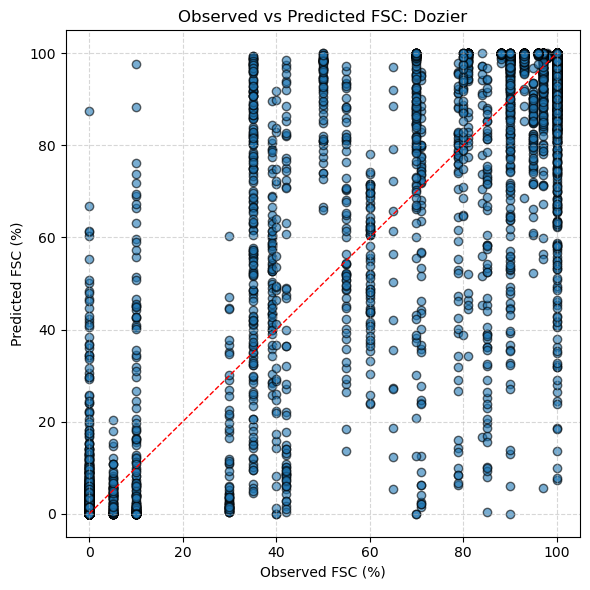

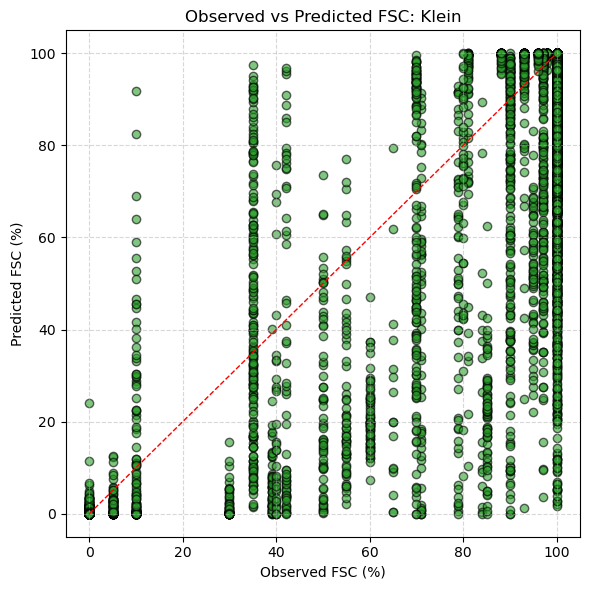

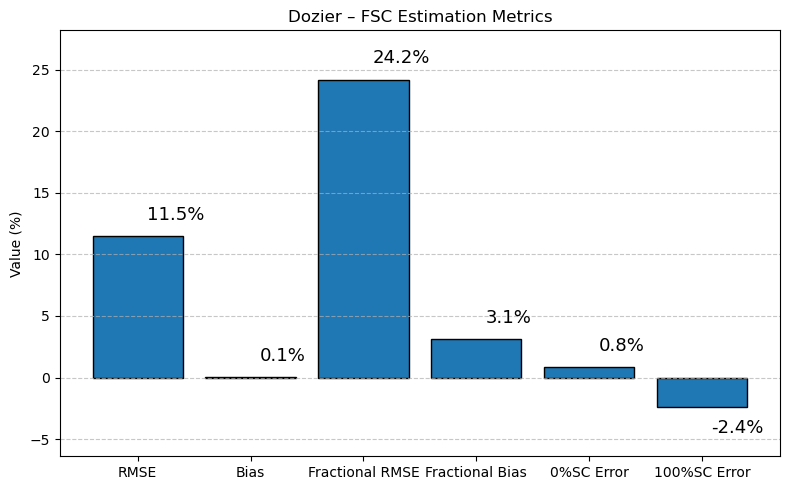

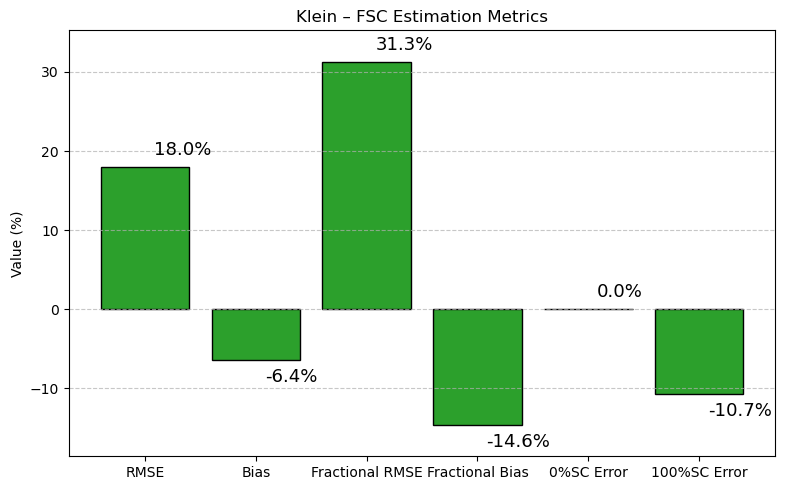

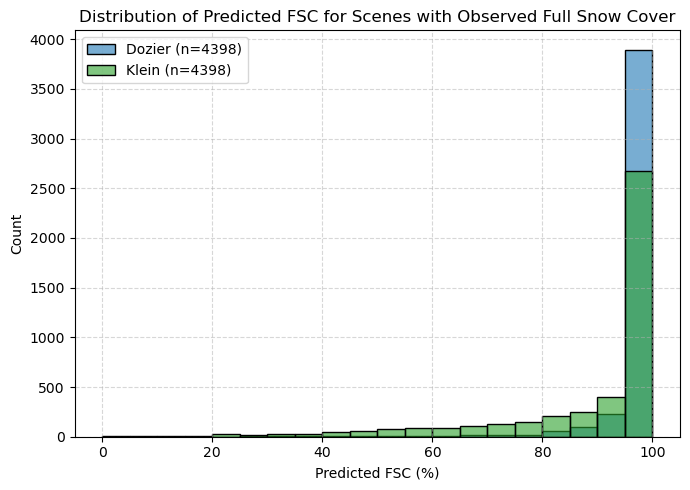

In [1]:
#80m

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

final_df = pd.read_pickle('landsat_aspect_results.pkl')

# final_df = pd.read_pickle('landsat_df_80m_0.2ff.pkl')
# final_df = final_df[final_df['cam']=='old_jack_pine']

# Melt the dataframe to long format for individual method plots
melted = final_df.melt(
    id_vars=["fsc", "filtered_fraction", "cam"],
    value_vars=["Dozier", "Klein"],  # , "Salomonson"
    var_name="method",
    value_name="predicted"
)

# Convert to percentages for plotting (0–100)
melted["fsc"] = melted["fsc"] * 100.0
melted["predicted"] = melted["predicted"] * 100.0

# Define color map (blue for Dozier, green for Klein)
method_colors = {
    "Dozier": "#1f77b4",
    "Klein": "#2ca02c",
    # "Salomonson": "#d62728"
}

# ---------- Scatter: Observed vs Predicted, one figure per method ----------
for method in ["Dozier", "Klein"]:  # , "Salomonson"
    subset = melted[melted["method"] == method]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        subset["fsc"],
        subset["predicted"],
        alpha=0.6,
        edgecolor='k',
        c=method_colors[method],
        label=method
    )
    plt.plot([0, 100], [0, 100], 'r--', lw=1)
    plt.xlabel("Observed FSC (%)")
    plt.ylabel("Predicted FSC (%)")
    plt.title(f"Observed vs Predicted FSC: {method}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_actual_predicted.svg')
    plt.show()

# ---------- Metric helpers ----------
def rmse(y_true, y_pred):
    diff = y_pred - y_true
    return np.sqrt(np.nanmean(diff**2)) if np.isfinite(diff).any() else np.nan

def bias(y_true, y_pred):
    diff = y_pred - y_true
    return np.nanmean(diff) if np.isfinite(diff).any() else np.nan

def compute_all_metrics(df_method):
    """df_method: melted subset for a single method, with fsc/predicted in 0–100 units."""
    y = df_method["fsc"].to_numpy()
    yhat = df_method["predicted"].to_numpy()

    # Overall
    overall_rmse  = rmse(y, yhat)
    overall_bias  = bias(y, yhat)

    # Fractional (strictly between 0 and 100)
    frac_mask = (y > 0) & (y < 100)
    frac_rmse  = rmse(y[frac_mask], yhat[frac_mask])
    frac_bias  = bias(y[frac_mask], yhat[frac_mask])

    # Errors at the extremes
    zero_mask = (y == 0)
    full_mask = (y == 100)

    zero_bias = bias(y[zero_mask], yhat[zero_mask])   # "0%SC Error"
    full_bias = bias(y[full_mask], yhat[full_mask])   # "100%SC Error"

    metrics_order = ["RMSE", "Bias", "Fractional RMSE", "Fractional Bias", "0%SC Error", "100%SC Error"]
    values = np.array([
        overall_rmse,
        overall_bias,
        frac_rmse,
        frac_bias,
        zero_bias,
        full_bias
    ], dtype=float)

    return metrics_order, values

# ---------- Bar chart per method with six metrics ----------
for method in ["Dozier", "Klein"]:
    subset = melted[melted["method"] == method]
    metrics_labels, values = compute_all_metrics(subset)

    plt.figure(figsize=(8, 5))
    x = np.arange(len(metrics_labels))
    bars = plt.bar(x, values, edgecolor='black', color=method_colors[method])

    # Labels on bars (handle NaNs gracefully)
    for bar, val in zip(bars, values):
        height = 0 if np.isnan(val) else float(val)
        txt = "NaN" if np.isnan(val) else f"{height:.1f}%"
        x_offset = bar.get_x() + bar.get_width() * 0.6
        y_offset = 1 * np.sign(height if height != 0 else 1)
        plt.text(
            x_offset,
            height + y_offset,
            txt,
            ha='left',
            va='bottom' if height >= 0 else 'top',
            fontsize=13
        )

    plt.xticks(x, metrics_labels, rotation=0)
    plt.ylabel("Value (%)")
    plt.title(f"{method} – FSC Estimation Metrics")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Y-lims with padding, robust to NaNs
    finite_vals = values[np.isfinite(values)]
    if finite_vals.size == 0:
        ymin, ymax = -1, 1
    else:
        ymin = min(0.0, float(finite_vals.min())) - 4
        ymax = (float(finite_vals.max()) + 4) if float(finite_vals.max()) > 0 else 1
    plt.ylim(ymin, ymax)

    plt.tight_layout()
    # plt.savefig(f'poster_landsat_{method}_metrics.svg')
    plt.show()

# ---------- Histogram: Predicted FSC where observed FSC = 100% ----------

# Filter scenes where observed FSC is 100%
full_snow = melted[melted["fsc"] == 100].copy()

# Set up plot
plt.figure(figsize=(7, 5))
bins = np.linspace(0, 100, 21)  # 0–100 in 5% increments

for method in ["Dozier", "Klein"]:
# for method in ["Klein"]:
    subset = full_snow[full_snow["method"] == method]
    sns.histplot(
        subset["predicted"],
        bins=bins,
        kde=False,
        color=method_colors[method],
        label=f"{method} (n={len(subset)})",
        alpha=0.6,
        edgecolor="black"
    )

# Reference line at 100% (perfect prediction)
# plt.axvline(100, color="red", linestyle="--", linewidth=1, label="Observed = 100%")

plt.xlabel("Predicted FSC (%)")
plt.ylabel("Count")
plt.title("Distribution of Predicted FSC for Scenes with Observed Full Snow Cover")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("poster_landsat_full_snow_hist.svg")
plt.show()

In [2]:
final_df.columns

Index(['sampling_mode', 'grid_row', 'grid_col', 'grid_cell_id', 'sim_id',
       'beam_pair', 'anchor_beam_pair', 'anchor_edge', 'orientation',
       'offset_m', 'lat_bin', 'lat_bin_y_min', 'lat_bin_y_max', 'track_x0',
       'track_y0', 'track_x1', 'track_y1', 'box_center_lon', 'box_center_lat',
       'box_center_x', 'box_center_y', 'box_left', 'box_right', 'box_bottom',
       'box_top', 'pixel_count', 'valid_pixel_count', 'filtered_fraction',
       'north_facing_fraction', 'aspect_variability', 'gradient_p16',
       'gradient_p50', 'gradient_p84', 'topography_valid_pixel_count',
       'ndsi_mean', 'ndsi_p16', 'ndsi_p50', 'ndsi_p84', 'ndvi_mean',
       'ndvi_p16', 'ndvi_p50', 'ndvi_p84', 'green_mean', 'green_p16',
       'green_p50', 'green_p84', 'red_mean', 'red_p16', 'red_p50', 'red_p84',
       'nir_mean', 'nir_p16', 'nir_p50', 'nir_p84', 'swir_mean', 'swir_p16',
       'swir_p50', 'swir_p84', 'Dozier', 'Klein', 'Salomonson', 'fsc', 'cam',
       'filepath', 'landsat_scene_i

In [13]:
# final_df[final_df['fsc']==1.00].filepath.unique()

In [14]:
final_df

,sampling_mode,grid_row,grid_col,grid_cell_id,sim_id,beam_pair,anchor_beam_pair,anchor_edge,orientation,offset_m,...,swir_p16,swir_p50,swir_p84,Dozier,Klein,Salomonson,fsc,cam,filepath,landsat_scene_index
0,regular_grid_cells,0,0,r0_c0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135480,0.170014,0.201670,0.025210,0.000000,0.012350,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
1,regular_grid_cells,0,1,r0_c1,NaN,NaN,NaN,NaN,NaN,NaN,...,0.118213,0.149869,0.178647,0.062706,0.004967,0.032267,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
2,regular_grid_cells,0,2,r0_c2,NaN,NaN,NaN,NaN,NaN,NaN,...,0.118443,0.152747,0.172892,0.091413,0.019553,0.039766,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
3,regular_grid_cells,0,4,r0_c4,NaN,NaN,NaN,NaN,NaN,NaN,...,0.123969,0.144114,0.161381,0.014440,0.000000,0.008906,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
4,regular_grid_cells,0,5,r0_c5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.123969,0.149869,0.167136,0.020888,0.007833,0.013176,0.71,delta_junction,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12157,regular_grid_cells,5,5,r5_c5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015351,0.033372,0.048457,0.826134,0.746220,0.876894,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248
12158,regular_grid_cells,5,6,r5_c6,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015775,0.023698,0.030631,0.762014,0.503433,0.829601,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248
12159,regular_grid_cells,6,4,r6_c4,NaN,NaN,NaN,NaN,NaN,NaN,...,0.027061,0.039225,0.053125,1.000000,0.963671,0.805782,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248
12160,regular_grid_cells,6,5,r6_c5,NaN,NaN,NaN,NaN,NaN,NaN,...,0.015386,0.020497,0.025775,0.762976,0.413495,0.856751,1.00,wslcreek,../scratch/data/landsat_oursites_L1_GEE/TOA/La...,248


Number of Landsat scenes: 249
Number of 0% or 100% scenes: 207
Processing i=4: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat7_marcell100_LE07_L1TP_028027_20200326_20200822_02_T1.tif
Landsat7 SR (as-is) mean/min/max: 46.435115814208984 -0.013624859042465687 275.9427185058594
marcell: reference=100% | valid-mask pixels=54,212 | common evaluated pixels=41,310
Processing i=17: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat8_bartlett0_LC08_L1TP_012029_20200926_20201006_02_T1.tif
Landsat8 SR (as-is) mean/min/max: 0.13015645742416382 0.005550930742174387 0.5961518287658691
bartlett: reference=0% | valid-mask pixels=27,070 | common evaluated pixels=26,632
Processing i=18: ../scratch/data/landsat_oursites_L1_GEE/TOA/Landsat8_bartlett0_LC08_L1TP_012029_20210524_20210529_02_T1.tif
Landsat8 SR (as-is) mean/min/max: 0.1337837278842926 -0.000430520303780213 0.6185896992683411
bartlett: reference=0% | valid-mask pixels=27,070 | common evaluated pixels=26,632
Processing i=19: ../scratch/dat

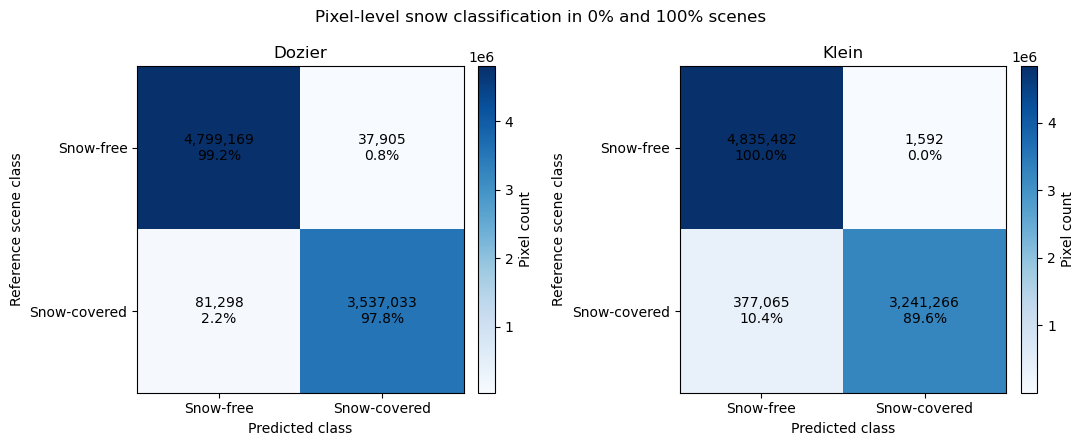

In [15]:
from scripts.imports import *
from rasterio.enums import Resampling
from shapely.geometry import Polygon, Point
from pyproj import Transformer
import os
import re
import gc
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------------
# positions for SR bands in your stacks (already reflectance)
L7_SR_IDX = slice(0, 6)   # SR_B1..SR_B5, SR_B7
L8_SR_IDX = slice(0, 7)   # SR_B1..SR_B7

USE_SIMULATED_TRACKS = False
PLOT_RGB_IMAGE = False
PLOT_SIMULATED_TRACKS = True
APPLY_MIN_FILTERED_FRACTION_TO_GRID_CELLS = True

PLOT_SNOW_PRODUCT_MAPS = False
PLOT_SALOMONSON_MAP = False

# Folder containing your reflectance Landsat stacks
LANDSAT_FOLDER = '../scratch/data/landsat_oursites_L1_GEE/TOA/'

# Topography data
LANDSAT_MASKING_FOLDER = '../scratch/data/landsat_masking/'

# WorldCover data
WC_FOLDER = '../scratch/data/WC/'
WC_FOREST_VALUE = 10

WC_NAME_MAP = {
    "sodankyla": "sodankyla_full",
    "marcell": "marcell_MN",
    "oregon": "oregon_yp",
}

# ROI options
USE_ROI = False
ROI_LON = -105.90
ROI_LAT = 53.92
ROI_HALF_WIDTH_M = 26000
ROI_HALF_HEIGHT_M = 26000

# Simulated ICESat-2 settings
N_TRACK_SIMS = 1
ICESAT2_PAIR_SPACING_M = 3300
ICESAT2_INCLINATION_DEG = 92
TRACK_LAT_BINS = 8
TRACK_BOX_SIZE_M = 1000
TRACK_MIN_FILTERED_FRACTION = 0.2
RNG_SEED = 42
N_BEAM_PAIRS = 1

# Regular grid-cell mode settings
GRID_N_X = 8
GRID_N_Y = 8
GRID_CELL_SIZE_M = 1000

# Spectral variables to summarise within each sampled cell.
# These include all direct inputs to the Dozier and Klein algorithms,
# plus the source bands used to calculate NDSI and NDVI.
SPECTRAL_VARIABLES = (
    "ndsi",
    "ndvi",
    "green",
    "red",
    "nir",
    "swir",
)


# ------------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------------
def _sr_slice(landsat_type):
    return L7_SR_IDX if landsat_type == 'Landsat7' else L8_SR_IDX


def extract_core_sr(landsat_da, landsat_type):
    """
    Return blue, green, red, nir, swir1 as reflectance,
    with consistent meanings across sensors.
    """
    if landsat_type == 'Landsat7':
        blue  = landsat_da.isel(band=0)
        green = landsat_da.isel(band=1)
        red   = landsat_da.isel(band=2)
        nir   = landsat_da.isel(band=3)
        swir1 = landsat_da.isel(band=4)
    else:
        blue  = landsat_da.isel(band=1)
        green = landsat_da.isel(band=2)
        red   = landsat_da.isel(band=3)
        nir   = landsat_da.isel(band=4)
        swir1 = landsat_da.isel(band=5)

    return blue, green, red, nir, swir1


def find_masks(masking_folder, wc_folder, cam):
    """
    Find:
      - WorldCover landcover from WC_FOLDER
      - ALOS elevation / gradient / aspect from LANDSAT_MASKING_FOLDER
    """
    wc_cam_name = WC_NAME_MAP.get(cam, cam)
    landcover_filepath = os.path.join(wc_folder, f"{wc_cam_name}.tif")

    elevation_filepath = None
    gradient_filepath = None
    aspect_filepath = None

    for filename in os.listdir(masking_folder):
        filename_lower = filename.lower()

        if (
            cam in filename
            and "elevation" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            elevation_filepath = os.path.join(masking_folder, filename)

        elif (
            cam in filename
            and "gradient" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            gradient_filepath = os.path.join(masking_folder, filename)

        elif (
            cam in filename
            and "aspect" in filename_lower
            and filename_lower.endswith(".tif")
        ):
            aspect_filepath = os.path.join(masking_folder, filename)

    if (
        not os.path.exists(landcover_filepath)
        or elevation_filepath is None
        or gradient_filepath is None
        or aspect_filepath is None
    ):
        raise FileNotFoundError(
            f"Could not find all required files for {cam}\n"
            f"  WorldCover expected: {landcover_filepath}\n"
            f"  ALOS elevation found: {elevation_filepath}\n"
            f"  ALOS gradient found:  {gradient_filepath}\n"
            f"  ALOS aspect found:    {aspect_filepath}"
        )

    return landcover_filepath, elevation_filepath, gradient_filepath, aspect_filepath


def load_and_reproject_to_landsat(source_path, match_array, band_name, method=Resampling.nearest):
    """
    Minimal memory-safe version of the original function.

    The important change is that the source raster is closed after
    reproject_match has created the matched output.
    """
    src = rioxarray.open_rasterio(source_path, masked=True).squeeze()
    src.name = band_name

    try:
        out = src.rio.reproject_match(match_array, resampling=method)
        out.name = band_name
    finally:
        try:
            src.close()
        except Exception:
            pass
        del src

    return out


def subset_roi(da, centre_lon, centre_lat, half_width_m, half_height_m):
    """
    Subset a DataArray to a rectangular ROI around lon/lat,
    using the dataset's CRS and units.
    """
    if da.rio.crs is None:
        raise ValueError("Dataset has no CRS; cannot subset by lon/lat.")

    transformer = Transformer.from_crs("EPSG:4326", da.rio.crs, always_xy=True)
    cx, cy = transformer.transform(centre_lon, centre_lat)

    minx = cx - half_width_m
    maxx = cx + half_width_m
    miny = cy - half_height_m
    maxy = cy + half_height_m

    return da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)


def combine_tifs(
    landsat_filepath,
    landcover_filepath,
    elevation_filepath,
    gradient_filepath,
    aspect_filepath,
    landsat_type,
    use_roi=False
):
    """
    Load Landsat reflectance stack + WorldCover landcover + elevation
    + gradient + aspect, all on the same Landsat grid.
    """
    landsat = rioxarray.open_rasterio(landsat_filepath, masked=True).squeeze()
    landsat.name = "landsat"

    if use_roi:
        print("  Applying ROI crop to Landsat...")
        landsat = subset_roi(
            landsat,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

    landcover = load_and_reproject_to_landsat(
        landcover_filepath,
        landsat,
        "landcover",
        method=Resampling.nearest
    )

    elevation = load_and_reproject_to_landsat(
        elevation_filepath,
        landsat,
        "elevation",
        method=Resampling.bilinear
    )

    gradient = load_and_reproject_to_landsat(
        gradient_filepath,
        landsat,
        "gradient",
        method=Resampling.bilinear
    )

    aspect = load_and_reproject_to_landsat(
        aspect_filepath,
        landsat,
        "aspect",
        method=Resampling.nearest
    )

    if use_roi:
        landcover = subset_roi(
            landcover,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        elevation = subset_roi(
            elevation,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        gradient = subset_roi(
            gradient,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

        aspect = subset_roi(
            aspect,
            centre_lon=ROI_LON,
            centre_lat=ROI_LAT,
            half_width_m=ROI_HALF_WIDTH_M,
            half_height_m=ROI_HALF_HEIGHT_M,
        )

    ds = xr.merge([landsat, landcover, elevation, gradient, aspect])

    # Remove local references. The merged Dataset keeps what it needs.
    del landcover, elevation, gradient, aspect

    return ds


def apply_valid_mask(ds, e=80):
    elevation = ds['elevation']
    landcover = ds['landcover']

    yc, xc = elevation.sizes['y'] // 2, elevation.sizes['x'] // 2
    centre_elev = elevation.isel(y=yc, x=xc).item()

    elev_mask = np.abs(elevation - centre_elev) <= e

    # ESA WorldCover class 10 = tree cover / forest
    landcover_mask = landcover == WC_FOREST_VALUE

    valid_mask = elev_mask & landcover_mask
    ds['valid_mask'] = valid_mask

    return ds


def compute_index(b1, b2):
    denom = b1 + b2
    return xr.where(denom != 0, (b1 - b2) / denom, np.nan)


def compute_dozier(ds, ndsi, nir):
    condition1 = (ndsi > 0.1) & (ndsi < 0.4)
    condition2 = (ndsi >= 0.4) & (nir > 0.11)
    dozier = xr.where(condition1 | condition2, 1, 0)
    return dozier.where(~np.isnan(ndsi))


def compute_klein(ndsi, ndvi, green, nir):
    region_coords = [
        (0.4, 1),
        (0.4, 0.1),
        (0.1, 0.24516133),
        (0.1125, 0.29378870),
        (0.125, 0.34092437),
        (0.175, 0.51454990),
        (0.2, 0.59241240),
        (0.25, 0.73023683),
        (0.275, 0.79019879),
        (0.325, 0.89222209)
    ]

    polygon = Polygon(region_coords)
    klein = xr.zeros_like(ndsi)
    klein = xr.where((ndsi >= 0.4) & (nir > 0.11), 1, klein)

    ndsi_vals = ndsi.values
    ndvi_vals = ndvi.values
    mask = np.zeros(ndsi.shape, dtype=bool)

    for i in range(ndsi.shape[0]):
        for j in range(ndsi.shape[1]):
            if not np.isnan(ndsi_vals[i, j]) and not np.isnan(ndvi_vals[i, j]):
                if polygon.contains(Point(ndsi_vals[i, j], ndvi_vals[i, j])):
                    mask[i, j] = True

    klein = xr.where(
        xr.DataArray(mask, dims=ndsi.dims, coords=ndsi.coords),
        1,
        klein
    )

    klein = xr.where((green <= 0.1), 0, klein)

    out = klein.where(~np.isnan(ndsi) & ~np.isnan(ndvi))

    # Minimal cleanup of the full numpy arrays used inside this function.
    del ndsi_vals, ndvi_vals, mask

    return out


def compute_salomonson(ndsi):
    fsc = 0.06 + 1.21 * ndsi
    return fsc.clip(0, 1).where(~np.isnan(ndsi))


def normalize(img):
    img = img.transpose("y", "x", "band")
    p2 = img.quantile(0.02, dim=("x", "y"))
    p98 = img.quantile(0.98, dim=("x", "y"))
    return ((img - p2) / (p98 - p2)).clip(0, 1)


def plot_rgb_with_tracks(ds, landsat_type, cam, track_stats=None, filtered=False):
    blue, green, red, _, _ = extract_core_sr(ds['landsat'], landsat_type)
    rgb = xr.concat([red, green, blue], dim='band')

    if filtered and 'valid_mask' in ds:
        rgb = rgb.where(ds['valid_mask'])

    rgb = normalize(rgb)
    rgb_img = rgb.transpose("y", "x", "band").values

    x_vals = ds["x"].values
    y_vals = ds["y"].values

    x_min, x_max = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    y_min, y_max = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.imshow(
        rgb_img,
        extent=[x_min, x_max, y_min, y_max],
        origin="upper"
    )

    if track_stats is not None and not track_stats.empty:
        sim_ids = sorted(track_stats["sim_id"].dropna().unique())
        cmap = plt.cm.tab10
        sim_colors = {
            sim_id: cmap((int(sim_id) - 1) % 10)
            for sim_id in sim_ids
        }

        track_cols = [
            "sim_id", "beam_pair",
            "track_x0", "track_y0",
            "track_x1", "track_y1",
            "anchor_beam_pair",
            "orientation"
        ]

        unique_tracks = (
            track_stats[track_cols]
            .drop_duplicates()
            .dropna(subset=["track_x0", "track_y0", "track_x1", "track_y1"])
        )

        for _, tr in unique_tracks.iterrows():
            sim_id = tr["sim_id"]
            beam_pair = int(tr["beam_pair"])
            color = sim_colors[sim_id]

            is_anchor = beam_pair == int(tr["anchor_beam_pair"])

            ax.plot(
                [tr["track_x0"], tr["track_x1"]],
                [tr["track_y0"], tr["track_y1"]],
                color=color,
                linewidth=2.4 if is_anchor else 1.5,
                linestyle="-" if is_anchor else "--",
                alpha=0.95,
                zorder=5
            )

            ax.text(
                tr["track_x0"],
                tr["track_y0"],
                f"S{int(sim_id)}-BP{beam_pair}",
                color=color,
                fontsize=8,
                weight="bold" if is_anchor else "normal",
                zorder=7
            )

        for _, row in track_stats.iterrows():
            color = sim_colors[row["sim_id"]]

            rect = Rectangle(
                (row["box_left"], row["box_bottom"]),
                row["box_right"] - row["box_left"],
                row["box_top"] - row["box_bottom"],
                fill=False,
                edgecolor=color,
                linewidth=1.2,
                alpha=0.85,
                zorder=6
            )
            ax.add_patch(rect)

            ax.scatter(
                row["box_center_x"],
                row["box_center_y"],
                s=12,
                color=color,
                zorder=8
            )

        legend_handles = [
            Line2D(
                [0], [0],
                color=sim_colors[sim_id],
                lw=2,
                label=f"Simulation {int(sim_id)}"
            )
            for sim_id in sim_ids
        ]

        legend_handles.extend([
            Line2D([0], [0], color="black", lw=2.4, linestyle="-", label="Anchor beam pair"),
            Line2D([0], [0], color="black", lw=1.5, linestyle="--", label="Offset beam pair"),
            Rectangle((0, 0), 1, 1, fill=False, edgecolor="black", label="1 km box")
        ])

        ax.legend(
            handles=legend_handles,
            loc="upper right",
            fontsize=8,
            frameon=True
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# PER-SCENE PROCESSING
# ------------------------------------------------------------------
def process_scene(i, apply_filter=True, e=80):
    cams = [
        'bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova',
        'lacclair', 'marcell', 'old_jack_pine', 'oregon', 'queens',
        'sodankyla', 'tammela', 'torgnon', 'underc', 'underhill',
        'varrio', 'willowcreek', 'wslcreek'
    ]

    landsat_filepaths = sorted([
        os.path.join(LANDSAT_FOLDER, f) for f in os.listdir(LANDSAT_FOLDER)
        if os.path.isfile(os.path.join(LANDSAT_FOLDER, f)) and f.endswith('.tif')
    ])

    filepath = landsat_filepaths[i]

    cam = [c for c in cams if c in filepath][0]
    landsat_type = [l for l in ['Landsat7', 'Landsat8'] if l in filepath][0]

    match = re.search(rf"{cam}(\d+)_", os.path.basename(filepath))
    fsc_value = int(match.group(1)) if match else None

    landcover_fp, elev_fp, gradient_fp, aspect_fp = find_masks(
        LANDSAT_MASKING_FOLDER,
        WC_FOLDER,
        cam
    )

    print(f"Processing i={i}: {filepath}")

    ds = combine_tifs(
        filepath,
        landcover_fp,
        elev_fp,
        gradient_fp,
        aspect_fp,
        landsat_type=landsat_type,
        use_roi=USE_ROI
    )

    ds = apply_valid_mask(ds, e)

    sr_subset = ds['landsat'].isel(band=_sr_slice(landsat_type))
    print(
        f"{landsat_type} SR (as-is) mean/min/max:",
        float(np.nanmean(sr_subset.values)),
        float(np.nanmin(sr_subset.values)),
        float(np.nanmax(sr_subset.values))
    )

    blue, green, red, nir, swir = extract_core_sr(ds['landsat'], landsat_type)

    ndsi = compute_index(green, swir)
    ndvi = compute_index(nir, red)

    dozier = compute_dozier(ds, ndsi, nir)
    klein = compute_klein(ndsi, ndvi, green, nir)
    fsc = compute_salomonson(ndsi)

    if apply_filter:
        dozier = dozier.where(ds['valid_mask'])
        klein = klein.where(ds['valid_mask'])
        fsc = fsc.where(ds['valid_mask'])

    # Retain the spectral variables already used to calculate the snow products
    # so they can be summarised for each sampled 1 km cell later.
    ds['ndsi'] = ndsi.assign_attrs(name="ndsi")
    ds['ndvi'] = ndvi.assign_attrs(name="ndvi")
    ds['green'] = green.assign_attrs(name="green")
    ds['red'] = red.assign_attrs(name="red")
    ds['nir'] = nir.assign_attrs(name="nir")
    ds['swir'] = swir.assign_attrs(name="swir")

    ds['Dozier'] = dozier.assign_attrs(name="Dozier")
    ds['Klein'] = klein.assign_attrs(name="Klein")
    ds['Salomonson'] = fsc.assign_attrs(name="Salomonson")

    # Minimal cleanup of temporary per-scene arrays now stored in ds.
    del sr_subset, blue, green, red, nir, swir, ndsi, ndvi, dozier, klein, fsc
    gc.collect()

    return ds, fsc_value, cam, filepath


# ------------------------------------------------------------------
# SIMULATED ICESAT-2 TRACK STATS
# ------------------------------------------------------------------
def get_roi_bounds(ds):
    x = ds['x'].values
    y = ds['y'].values

    return (
        float(np.nanmin(x)),
        float(np.nanmax(x)),
        float(np.nanmin(y)),
        float(np.nanmax(y)),
    )


def line_rectangle_intersection(p0, direction, bounds, eps=1e-12):
    x_min, x_max, y_min, y_max = bounds

    t_min = -np.inf
    t_max = np.inf

    for p, d, lo, hi in [
        (p0[0], direction[0], x_min, x_max),
        (p0[1], direction[1], y_min, y_max),
    ]:
        if abs(d) < eps:
            if p < lo or p > hi:
                return None
        else:
            t1 = (lo - p) / d
            t2 = (hi - p) / d

            t_lo = min(t1, t2)
            t_hi = max(t1, t2)

            t_min = max(t_min, t_lo)
            t_max = min(t_max, t_hi)

            if t_min > t_max:
                return None

    p_start = p0 + t_min * direction
    p_end = p0 + t_max * direction

    return p_start, p_end


def track_vectors_from_orientation(orientation, inclination_deg=92):
    angle_from_horizontal = 180.0 - inclination_deg

    if orientation == "ascending":
        theta = np.deg2rad(angle_from_horizontal)
    elif orientation == "descending":
        theta = np.deg2rad(-angle_from_horizontal)
    else:
        raise ValueError("orientation must be 'ascending' or 'descending'")

    along = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    along = along / np.linalg.norm(along)

    across = np.array([-along[1], along[0]], dtype=float)
    across = across / np.linalg.norm(across)

    if across[0] < 0:
        across = -across

    return along, across


def simulate_track_set(bounds, rng,
                       pair_spacing_m=3300,
                       inclination_deg=92,
                       n_beam_pairs=3):
    x_min, x_max, y_min, y_max = bounds

    beam_pairs = list(range(1, n_beam_pairs + 1))

    anchor_beam_pair = int(rng.choice(beam_pairs))
    edge = str(rng.choice(["top", "bottom"]))
    edge_x = float(rng.uniform(x_min, x_max))
    edge_y = y_max if edge == "top" else y_min

    orientation = str(rng.choice(["ascending", "descending"]))

    along, across = track_vectors_from_orientation(
        orientation=orientation,
        inclination_deg=inclination_deg
    )

    anchor_point = np.array([edge_x, edge_y], dtype=float)

    tracks = []

    for beam_pair in beam_pairs:
        offset_m = (beam_pair - anchor_beam_pair) * pair_spacing_m
        p0 = anchor_point + offset_m * across

        segment = line_rectangle_intersection(p0, along, bounds)

        row = {
            "beam_pair": beam_pair,
            "anchor_beam_pair": anchor_beam_pair,
            "anchor_edge": edge,
            "anchor_edge_x": edge_x,
            "anchor_edge_y": edge_y,
            "orientation": orientation,
            "offset_m": offset_m,
            "intersects_roi": segment is not None,
        }

        if segment is None:
            row.update({
                "track_x0": np.nan,
                "track_y0": np.nan,
                "track_x1": np.nan,
                "track_y1": np.nan,
            })
        else:
            p_start, p_end = segment
            row.update({
                "track_x0": float(p_start[0]),
                "track_y0": float(p_start[1]),
                "track_x1": float(p_end[0]),
                "track_y1": float(p_end[1]),
            })

        tracks.append(row)

    return pd.DataFrame(tracks)


def segment_midpoint_in_y_bin(p_start, p_end, y_bin_min, y_bin_max, eps=1e-12):
    p_start = np.asarray(p_start, dtype=float)
    p_end = np.asarray(p_end, dtype=float)

    dy = p_end[1] - p_start[1]

    if abs(dy) < eps:
        y = p_start[1]
        if y_bin_min <= y <= y_bin_max:
            return (p_start + p_end) / 2
        return None

    t_a = (y_bin_min - p_start[1]) / dy
    t_b = (y_bin_max - p_start[1]) / dy

    t_low = min(t_a, t_b)
    t_high = max(t_a, t_b)

    t0 = max(0.0, t_low)
    t1 = min(1.0, t_high)

    if t0 > t1:
        return None

    t_mid = 0.5 * (t0 + t1)
    midpoint = p_start + t_mid * (p_end - p_start)

    return midpoint


def box_mask_for_ds(ds, left, right, bottom, top):
    x_mask = (ds['x'] >= left) & (ds['x'] <= right)
    y_mask = (ds['y'] >= bottom) & (ds['y'] <= top)

    return x_mask & y_mask


def summarize_topography_in_box(ds, box_mask):
    """
    Summarise gradient and aspect inside one cell, using the same valid area
    as the snow products.
    """
    if "gradient" not in ds or "aspect" not in ds:
        return {
            "north_facing_fraction": np.nan,
            "aspect_variability": np.nan,
            "gradient_p16": np.nan,
            "gradient_p50": np.nan,
            "gradient_p84": np.nan,
            "topography_valid_pixel_count": 0,
        }

    topo_mask = ds["valid_mask"] & box_mask

    gradient_arr = ds["gradient"].where(topo_mask, drop=True).values
    aspect_arr = ds["aspect"].where(topo_mask, drop=True).values

    gradient_vals = gradient_arr[np.isfinite(gradient_arr)]
    aspect_vals = aspect_arr[np.isfinite(aspect_arr)]

    out = {
        "north_facing_fraction": np.nan,
        "aspect_variability": np.nan,
        "gradient_p16": np.nan,
        "gradient_p50": np.nan,
        "gradient_p84": np.nan,
        "topography_valid_pixel_count": int(len(aspect_vals)),
    }

    if len(aspect_vals) > 0:
        aspect_vals = aspect_vals % 360

        north_mask = (aspect_vals >= 270) | (aspect_vals < 90)
        out["north_facing_fraction"] = float(np.mean(north_mask))

        aspect_rad = np.deg2rad(aspect_vals)
        mean_sin = np.mean(np.sin(aspect_rad))
        mean_cos = np.mean(np.cos(aspect_rad))
        resultant_length = np.sqrt(mean_sin**2 + mean_cos**2)

        out["aspect_variability"] = float(1 - resultant_length)

    if len(gradient_vals) > 0:
        out["gradient_p16"] = float(np.nanpercentile(gradient_vals, 16))
        out["gradient_p50"] = float(np.nanpercentile(gradient_vals, 50))
        out["gradient_p84"] = float(np.nanpercentile(gradient_vals, 84))

    return out


def summarize_spectral_in_box(
    ds,
    box_mask,
    variables=SPECTRAL_VARIABLES
):
    """
    Summarise Landsat spectral variables inside one sampled cell, using the
    same valid mask and spatial box as the existing snow-product summaries.

    For each variable, save the mean and the 16th, 50th, and 84th
    percentiles.
    """
    out = {}

    for var in variables:
        prefix = var.lower()

        if var not in ds:
            out[f"{prefix}_mean"] = np.nan
            out[f"{prefix}_p16"] = np.nan
            out[f"{prefix}_p50"] = np.nan
            out[f"{prefix}_p84"] = np.nan
            continue

        # Match the existing snow-product masking pattern: first apply the
        # valid forest/elevation mask, then crop to the current spatial box.
        # Applying drop=True only to box_mask avoids the empty-mask failure
        # that occurs when a cell contains no valid pixels.
        arr = (
            ds[var]
            .where(ds['valid_mask'])
            .where(box_mask, drop=True)
            .values
        )

        vals = arr[np.isfinite(arr)]

        if vals.size == 0:
            out[f"{prefix}_mean"] = np.nan
            out[f"{prefix}_p16"] = np.nan
            out[f"{prefix}_p50"] = np.nan
            out[f"{prefix}_p84"] = np.nan
        else:
            out[f"{prefix}_mean"] = float(np.mean(vals))
            out[f"{prefix}_p16"] = float(np.percentile(vals, 16))
            out[f"{prefix}_p50"] = float(np.percentile(vals, 50))
            out[f"{prefix}_p84"] = float(np.percentile(vals, 84))

    return out


def summarize_track_box(ds, centre_x, centre_y, bounds,
                        variables=("Dozier", "Klein", "Salomonson"),
                        box_size_m=1000):
    x_min, x_max, y_min, y_max = bounds
    half = box_size_m / 2

    left = max(x_min, centre_x - half)
    right = min(x_max, centre_x + half)
    bottom = max(y_min, centre_y - half)
    top = min(y_max, centre_y + half)

    if left >= right or bottom >= top:
        return None

    box_mask = box_mask_for_ds(ds, left, right, bottom, top)

    valid_box = ds['valid_mask'].where(box_mask, drop=True)

    if valid_box.size == 0:
        return None

    pixel_count = int(valid_box.size)
    valid_pixel_count = int(np.count_nonzero(valid_box.values == True))

    filtered_fraction = (
        valid_pixel_count / pixel_count
        if pixel_count > 0 else np.nan
    )

    out = {
        "box_center_x": float(centre_x),
        "box_center_y": float(centre_y),
        "box_left": float(left),
        "box_right": float(right),
        "box_bottom": float(bottom),
        "box_top": float(top),
        "pixel_count": pixel_count,
        "valid_pixel_count": valid_pixel_count,
        "filtered_fraction": filtered_fraction,
    }

    topo_stats = summarize_topography_in_box(ds, box_mask)
    out.update(topo_stats)

    spectral_stats = summarize_spectral_in_box(ds, box_mask)
    out.update(spectral_stats)

    for var in variables:
        arr = ds[var].where(ds['valid_mask']).where(box_mask, drop=True)

        if arr.size == 0:
            out[var] = np.nan
        else:
            val = arr.mean(skipna=True).item()
            out[var] = float(val) if np.isfinite(val) else np.nan

    return out


def simulated_icesat2_box_stats(ds,
                                variables=("Dozier", "Klein", "Salomonson"),
                                n_sims=1,
                                lat_bins=8,
                                box_size_m=1000,
                                pair_spacing_m=3300,
                                inclination_deg=92,
                                n_beam_pairs=3,
                                rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if ds.rio.crs is not None and ds.rio.crs.is_geographic:
        raise ValueError(
            "This simulated-track code assumes x/y are projected metres, "
            "but ds.rio.crs appears to be geographic. Reproject first."
        )

    bounds = get_roi_bounds(ds)
    x_min, x_max, y_min, y_max = bounds

    y_edges = np.linspace(y_min, y_max, lat_bins + 1)

    transformer_to_lonlat = None
    if ds.rio.crs is not None:
        transformer_to_lonlat = Transformer.from_crs(
            ds.rio.crs,
            "EPSG:4326",
            always_xy=True
        )

    rows = []

    for sim_id in range(1, n_sims + 1):
        tracks = simulate_track_set(
            bounds=bounds,
            rng=rng,
            pair_spacing_m=pair_spacing_m,
            inclination_deg=inclination_deg,
            n_beam_pairs=n_beam_pairs
        )

        for _, tr in tracks.iterrows():
            if not bool(tr["intersects_roi"]):
                continue

            p_start = np.array([tr["track_x0"], tr["track_y0"]], dtype=float)
            p_end = np.array([tr["track_x1"], tr["track_y1"]], dtype=float)

            for lat_bin in range(lat_bins):
                y_bin_min = y_edges[lat_bin]
                y_bin_max = y_edges[lat_bin + 1]

                midpoint = segment_midpoint_in_y_bin(
                    p_start=p_start,
                    p_end=p_end,
                    y_bin_min=y_bin_min,
                    y_bin_max=y_bin_max
                )

                if midpoint is None:
                    continue

                centre_x = float(midpoint[0])
                centre_y = float(midpoint[1])

                box_stats = summarize_track_box(
                    ds=ds,
                    centre_x=centre_x,
                    centre_y=centre_y,
                    bounds=bounds,
                    variables=variables,
                    box_size_m=box_size_m
                )

                if box_stats is None:
                    continue

                if transformer_to_lonlat is not None:
                    centre_lon, centre_lat = transformer_to_lonlat.transform(
                        centre_x,
                        centre_y
                    )
                else:
                    centre_lon, centre_lat = np.nan, np.nan

                row = {
                    "sim_id": sim_id,
                    "beam_pair": int(tr["beam_pair"]),
                    "anchor_beam_pair": int(tr["anchor_beam_pair"]),
                    "anchor_edge": tr["anchor_edge"],
                    "orientation": tr["orientation"],
                    "offset_m": float(tr["offset_m"]),
                    "lat_bin": int(lat_bin),
                    "lat_bin_y_min": float(y_bin_min),
                    "lat_bin_y_max": float(y_bin_max),
                    "track_x0": float(tr["track_x0"]),
                    "track_y0": float(tr["track_y0"]),
                    "track_x1": float(tr["track_x1"]),
                    "track_y1": float(tr["track_y1"]),
                    "box_center_lon": float(centre_lon),
                    "box_center_lat": float(centre_lat),
                }

                row.update(box_stats)
                rows.append(row)

    return pd.DataFrame(rows)


def summarize_regular_grid_cells(
    ds,
    variables=("Dozier", "Klein", "Salomonson"),
    n_x=8,
    n_y=8,
    cell_size_m=1000
):
    bounds = get_roi_bounds(ds)
    x_min, x_max, y_min, y_max = bounds

    image_center_x = (x_min + x_max) / 2
    image_center_y = (y_min + y_max) / 2

    grid_width = n_x * cell_size_m
    grid_height = n_y * cell_size_m

    grid_left = image_center_x - grid_width / 2
    grid_right = image_center_x + grid_width / 2
    grid_bottom = image_center_y - grid_height / 2
    grid_top = image_center_y + grid_height / 2

    transformer_to_lonlat = None
    if ds.rio.crs is not None:
        transformer_to_lonlat = Transformer.from_crs(
            ds.rio.crs,
            "EPSG:4326",
            always_xy=True
        )

    rows = []

    for row_idx in range(n_y):
        for col_idx in range(n_x):

            cell_left = grid_left + col_idx * cell_size_m
            cell_right = cell_left + cell_size_m

            cell_top = grid_top - row_idx * cell_size_m
            cell_bottom = cell_top - cell_size_m

            centre_x = (cell_left + cell_right) / 2
            centre_y = (cell_bottom + cell_top) / 2

            box_stats = summarize_track_box(
                ds=ds,
                centre_x=centre_x,
                centre_y=centre_y,
                bounds=bounds,
                variables=variables,
                box_size_m=cell_size_m
            )

            if box_stats is None:
                continue

            if transformer_to_lonlat is not None:
                centre_lon, centre_lat = transformer_to_lonlat.transform(
                    centre_x,
                    centre_y
                )
            else:
                centre_lon, centre_lat = np.nan, np.nan

            out = {
                "sampling_mode": "regular_grid_cells",
                "grid_row": int(row_idx),
                "grid_col": int(col_idx),
                "grid_cell_id": f"r{row_idx}_c{col_idx}",

                "sim_id": np.nan,
                "beam_pair": np.nan,
                "anchor_beam_pair": np.nan,
                "anchor_edge": np.nan,
                "orientation": np.nan,
                "offset_m": np.nan,
                "lat_bin": np.nan,
                "lat_bin_y_min": np.nan,
                "lat_bin_y_max": np.nan,
                "track_x0": np.nan,
                "track_y0": np.nan,
                "track_x1": np.nan,
                "track_y1": np.nan,

                "box_center_lon": float(centre_lon),
                "box_center_lat": float(centre_lat),
            }

            out.update(box_stats)
            rows.append(out)

    return pd.DataFrame(rows)


def overlay_track_geometry(ax, track_stats):
    if track_stats is None or track_stats.empty:
        return

    sim_ids = sorted(track_stats["sim_id"].dropna().unique())
    cmap = plt.cm.tab10
    sim_colors = {
        sim_id: cmap((int(sim_id) - 1) % 10)
        for sim_id in sim_ids
    }

    track_cols = [
        "sim_id", "beam_pair",
        "track_x0", "track_y0",
        "track_x1", "track_y1",
        "anchor_beam_pair",
        "orientation"
    ]

    unique_tracks = (
        track_stats[track_cols]
        .drop_duplicates()
        .dropna(subset=["track_x0", "track_y0", "track_x1", "track_y1"])
    )

    for _, tr in unique_tracks.iterrows():
        sim_id = tr["sim_id"]
        beam_pair = int(tr["beam_pair"])
        color = sim_colors[sim_id]

        is_anchor = beam_pair == int(tr["anchor_beam_pair"])

        ax.plot(
            [tr["track_x0"], tr["track_x1"]],
            [tr["track_y0"], tr["track_y1"]],
            color=color,
            linewidth=2.4 if is_anchor else 1.5,
            linestyle="-" if is_anchor else "--",
            alpha=0.95,
            zorder=5
        )

    for _, row in track_stats.iterrows():
        color = sim_colors[row["sim_id"]]

        rect = Rectangle(
            (row["box_left"], row["box_bottom"]),
            row["box_right"] - row["box_left"],
            row["box_top"] - row["box_bottom"],
            fill=False,
            edgecolor=color,
            linewidth=1.2,
            alpha=0.85,
            zorder=6
        )
        ax.add_patch(rect)


def plot_snow_product_maps(
    ds,
    cam,
    products=("Dozier", "Klein", "Salomonson"),
    filtered=True,
    track_stats=None
):
    products = list(products)

    if not PLOT_SALOMONSON_MAP:
        products = [p for p in products if p != "Salomonson"]

    products = [p for p in products if p in ds]

    if len(products) == 0:
        print("No snow products available to plot.")
        return

    x_vals = ds["x"].values
    y_vals = ds["y"].values

    x_min, x_max = float(np.nanmin(x_vals)), float(np.nanmax(x_vals))
    y_min, y_max = float(np.nanmin(y_vals)), float(np.nanmax(y_vals))

    n_products = len(products)

    fig, axes = plt.subplots(
        1,
        n_products,
        figsize=(5 * n_products, 5),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, product in zip(axes, products):
        arr = ds[product]

        if filtered and "valid_mask" in ds:
            arr = arr.where(ds["valid_mask"])

        im = ax.imshow(
            arr.values,
            extent=[x_min, x_max, y_min, y_max],
            origin="upper",
            vmin=0,
            vmax=1,
            interpolation="none"
        )

        overlay_track_geometry(ax, track_stats)

        if product in ["Dozier", "Klein"]:
            title = f"{product}"
            cbar_label = "Snow classification"
            cbar_ticks = [0, 1]
            cbar_ticklabels = ["No snow", "Snow"]
        else:
            title = f"{product} fractional snow map"
            cbar_label = "Fractional snow cover"
            cbar_ticks = None
            cbar_ticklabels = None

        ax.set_title(title)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect("equal")

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)

        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)
            cbar.set_ticklabels(cbar_ticklabels)

    fig.suptitle(f"Snow product maps for {cam}", y=1.02)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# PIXEL-LEVEL CONFUSION-MATRIX HELPERS
# ------------------------------------------------------------------
CONFUSION_METHODS = ("Dozier", "Klein")
CLASS_LABELS = ["Snow-free", "Snow-covered"]


def get_scene_fsc_from_filename(filepath):
    """Return the reference scene snow cover encoded after the site name."""
    cams = [
        'bartlett', 'delta_junction', 'glees', 'hyytiala', 'kenttarova',
        'lacclair', 'marcell', 'old_jack_pine', 'oregon', 'queens',
        'sodankyla', 'tammela', 'torgnon', 'underc', 'underhill',
        'varrio', 'willowcreek', 'wslcreek'
    ]

    basename = os.path.basename(filepath)

    for cam in cams:
        match = re.search(rf"{re.escape(cam)}(\d+)_", basename)
        if match:
            return int(match.group(1))

    return None


def count_binary_predictions(prediction, truth_class, evaluation_mask):
    """
    Count one binary snow product against a scene-wide reference class.

    Matrix rows are reference classes and columns are predicted classes:
        [[true snow-free, false snow-covered],
         [false snow-free, true snow-covered]]
    """
    values = prediction.where(evaluation_mask).values
    values = values[np.isfinite(values)].astype(np.uint8)

    matrix = np.zeros((2, 2), dtype=np.int64)

    if values.size > 0:
        reference = np.full(values.size, truth_class, dtype=np.uint8)
        np.add.at(matrix, (reference, values), 1)

    return matrix


def matrix_metrics(matrix):
    """Calculate concise classification metrics from a 2 x 2 matrix."""
    tn, fp = matrix[0, 0], matrix[0, 1]
    fn, tp = matrix[1, 0], matrix[1, 1]

    def safe_divide(numerator, denominator):
        return numerator / denominator if denominator else np.nan

    snow_free_recall = safe_divide(tn, tn + fp)
    snow_covered_recall = safe_divide(tp, tp + fn)

    return {
        "evaluated_pixels": int(matrix.sum()),
        "accuracy": safe_divide(tn + tp, matrix.sum()),
        "snow_free_recall": snow_free_recall,
        "snow_covered_recall": snow_covered_recall,
        "balanced_accuracy": np.nanmean(
            [snow_free_recall, snow_covered_recall]
        ),
    }


def plot_binary_confusion_matrices(matrices):
    """Plot counts and row percentages for Dozier and Klein."""
    fig, axes = plt.subplots(1, len(CONFUSION_METHODS), figsize=(11, 4.5))

    if len(CONFUSION_METHODS) == 1:
        axes = [axes]

    for ax, method in zip(axes, CONFUSION_METHODS):
        matrix = matrices[method]
        row_totals = matrix.sum(axis=1, keepdims=True)
        row_percent = np.divide(
            matrix,
            row_totals,
            out=np.full(matrix.shape, np.nan, dtype=float),
            where=row_totals != 0,
        )

        image = ax.imshow(matrix, cmap="Blues")

        for row in range(2):
            for col in range(2):
                percent_text = (
                    f"{row_percent[row, col]:.1%}"
                    if np.isfinite(row_percent[row, col])
                    else "n/a"
                )
                ax.text(
                    col,
                    row,
                    f"{matrix[row, col]:,}\n{percent_text}",
                    ha="center",
                    va="center",
                    color="black",
                )

        ax.set_title(method)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("Reference scene class")
        ax.set_xticks([0, 1], labels=CLASS_LABELS)
        ax.set_yticks([0, 1], labels=CLASS_LABELS)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Pixel count")

    fig.suptitle("Pixel-level snow classification in 0% and 100% scenes")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# MAIN LOOP: ONLY 0% AND 100% REFERENCE SCENES
# ------------------------------------------------------------------
landsat_filepaths = sorted([
    os.path.join(LANDSAT_FOLDER, f)
    for f in os.listdir(LANDSAT_FOLDER)
    if os.path.isfile(os.path.join(LANDSAT_FOLDER, f)) and f.endswith(".tif")
])

binary_scene_indices = [
    i for i, filepath in enumerate(landsat_filepaths)
    if get_scene_fsc_from_filename(filepath) in (0, 100)
]

print("Number of Landsat scenes:", len(landsat_filepaths))
print("Number of 0% or 100% scenes:", len(binary_scene_indices))

confusion_counts = {
    method: np.zeros((2, 2), dtype=np.int64)
    for method in CONFUSION_METHODS
}
scene_confusion_rows = []
e = 80

for i in binary_scene_indices:
    ds = None

    try:
        ds, fsc, cam, filepath = process_scene(
            i=i,
            apply_filter=True,
            e=e,
        )

        truth_class = 0 if fsc == 0 else 1

        # Fair method comparison: both matrices use exactly the same pixels.
        # This retains the forest/elevation valid mask and also excludes any
        # pixel for which either algorithm lacks the spectral inputs needed to
        # produce a finite classification.
        evaluation_mask = (
            ds["valid_mask"].fillna(False)
            & ds["Dozier"].notnull()
            & ds["Klein"].notnull()
        )

        valid_mask_pixels = int(
            np.count_nonzero(ds["valid_mask"].fillna(False).values)
        )
        evaluated_pixels = int(np.count_nonzero(evaluation_mask.values))

        print(
            f"{cam}: reference={fsc}% | "
            f"valid-mask pixels={valid_mask_pixels:,} | "
            f"common evaluated pixels={evaluated_pixels:,}"
        )

        for method in CONFUSION_METHODS:
            scene_matrix = count_binary_predictions(
                prediction=ds[method],
                truth_class=truth_class,
                evaluation_mask=evaluation_mask,
            )

            confusion_counts[method] += scene_matrix

            scene_confusion_rows.append({
                "landsat_scene_index": i,
                "cam": cam,
                "filepath": filepath,
                "reference_fsc_percent": fsc,
                "reference_class": CLASS_LABELS[truth_class],
                "method": method,
                "valid_mask_pixels": valid_mask_pixels,
                "evaluated_pixels": int(scene_matrix.sum()),
                "true_snow_free": int(scene_matrix[0, 0]),
                "false_snow_covered": int(scene_matrix[0, 1]),
                "false_snow_free": int(scene_matrix[1, 0]),
                "true_snow_covered": int(scene_matrix[1, 1]),
            })

    finally:
        try:
            if ds is not None:
                ds.close()
        except Exception:
            pass

        del ds
        gc.collect()


# Per-scene audit table showing exactly which masked pixels were evaluated.
scene_confusion_df = pd.DataFrame(scene_confusion_rows)

# Pooled count matrices. Rows are the reference; columns are the prediction.
confusion_matrices = {
    method: pd.DataFrame(
        confusion_counts[method],
        index=pd.Index(CLASS_LABELS, name="Reference"),
        columns=pd.Index(CLASS_LABELS, name="Predicted"),
    )
    for method in CONFUSION_METHODS
}

# Row-normalized matrices answer: within each true class, what fraction was
# classified as snow-free versus snow-covered?
normalized_confusion_matrices = {}

for method in CONFUSION_METHODS:
    matrix = confusion_counts[method].astype(float)
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(
        matrix,
        row_totals,
        out=np.full(matrix.shape, np.nan, dtype=float),
        where=row_totals != 0,
    )

    normalized_confusion_matrices[method] = pd.DataFrame(
        normalized,
        index=pd.Index(CLASS_LABELS, name="Reference"),
        columns=pd.Index(CLASS_LABELS, name="Predicted"),
    )

metrics_df = pd.DataFrame([
    {"method": method, **matrix_metrics(confusion_counts[method])}
    for method in CONFUSION_METHODS
])

for method in CONFUSION_METHODS:
    print(f"\n{method} confusion matrix (pixel counts):")
    print(confusion_matrices[method])

    print(f"\n{method} confusion matrix (row proportions):")
    print(normalized_confusion_matrices[method])

print("\nSummary metrics:")
print(metrics_df)

plot_binary_confusion_matrices(confusion_counts)

# Optional saves:
# scene_confusion_df.to_pickle("landsat_binary_scene_pixel_confusion_by_scene.pkl")
# metrics_df.to_csv("landsat_binary_scene_pixel_confusion_metrics.csv", index=False)

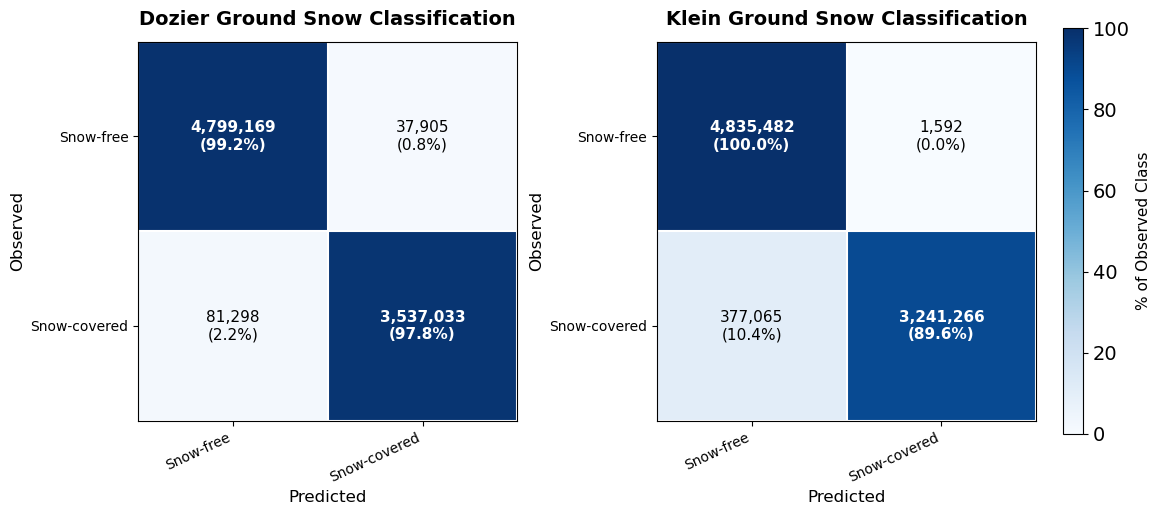

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Saved confusion-matrix counts from the previous run
# Rows = observed/reference class
# Columns = predicted class
confusion_matrices = {
    "Dozier Ground Snow Classification": np.array([
        [4_799_169,    37_905],
        [   81_298, 3_537_033]
    ]),
    "Klein Ground Snow Classification": np.array([
        [4_835_482,     1_592],
        [  377_065, 3_241_266]
    ])
}

classes = ["Snow-free", "Snow-covered"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(11.5, 5.2),
    constrained_layout=True
)

for ax, (method, cm) in zip(axes, confusion_matrices.items()):

    # Row-normalised percentages for colour and annotations
    row_totals = cm.sum(axis=1, keepdims=True)
    row_pct = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0
    ) * 100

    im = ax.imshow(
        row_pct,
        cmap="Blues",
        vmin=0,
        vmax=100
    )

    ax.set_title(
        method,
        fontsize=14,
        weight="bold",
        pad=12
    )

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Observed", fontsize=12)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(
        classes,
        rotation=25,
        ha="right",
        fontsize=10
    )
    ax.set_yticklabels(classes, fontsize=10)

    # Cell annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            colour = "white" if row_pct[i, j] > 50 else "black"
            weight = "bold" if i == j else "normal"

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}\n({row_pct[i, j]:.1f}%)",
                ha="center",
                va="center",
                color=colour,
                fontsize=11,
                weight=weight
            )

    # Subtle white grid between cells
    ax.set_xticks(
        np.arange(-0.5, len(classes), 1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-0.5, len(classes), 1),
        minor=True
    )
    ax.grid(
        which="minor",
        color="white",
        linewidth=1.5
    )
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

# Shared percentage colour bar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.88,
    pad=0.03
)
cbar.set_label("% of Observed Class", fontsize=11)

# fig.suptitle(
#     "Landsat Binary Snow Classification Accuracy for Ground",
#     fontsize=15,
#     weight="bold"
# )

plt.show()

33356
21089


/tmp/ipykernel_1201903/943716034.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Conditions"] = data["JointSnow"].map({0: "No Snow", 1: "Ground Snow", 2: "Ground and Canopy Snow"})


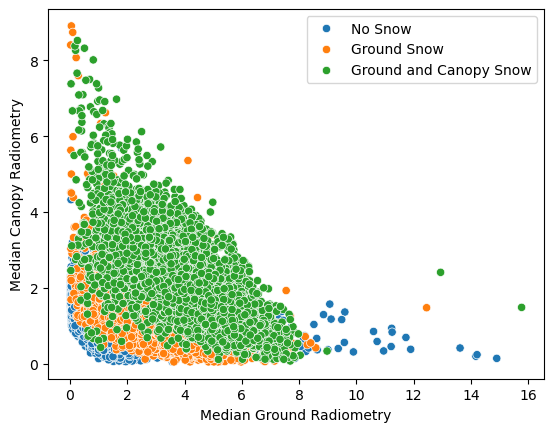

In [2]:
from scripts.imports import *

df = pd.read_pickle('dataset_lcforest_noLOF_bin30_th3_80m_1kmsmallbox_noprior_ta_wc1_v7.pkl')
# df = pd.read_pickle('dataset_lcforest_LOF10_bin30_th3_1km_noprior_ta.pkl')

# df = df_.copy()
# print(df)
# mask = df['beam'] == 3
# df.loc[mask, ['pv','pg','Ev','Eg']] /= 0.85

# First create masked columns
df['Eg_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_strong'] = np.where((df['beam_str'] == 'strong')&(df['outlier'] == 1), df['Ev'], np.nan)
df['Eg_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Eg'], np.nan)
df['Ev_weak'] = np.where((df['beam_str'] == 'weak')&(df['outlier'] == 1), df['Ev'], np.nan)
df['forest_type'] = np.where(df['segment_landcover']<119, 'closed', 'open')

df_grouped = df.copy()
# df_grouped = df.groupby(['camera','date','lat','lon']).agg({
#     'pvpg': 'mean',
#     'pv': 'max',
#     'pg': 'max',
#     'Eg_strong': 'mean',
#     'Ev_strong': 'mean',
#     'Eg_weak': 'median',
#     'Ev_weak': 'median',
#     'data_quantity': 'max',
#     'snr': 'mean',
#     'FSC': 'mean',
#     'TreeSnow': 'mean',
#     'layer_flag': 'mean',
#     'file_index': 'mean',
#     'msw_flag': 'mean',
#     'pv_ratio_mean': 'mean',
#     'pv_ratio_max': 'mean',
#     'forest_type': lambda x: pd.Series.mode(x).iloc[0],
# }).reset_index()
df_grouped = df_grouped[df_grouped['Eg_strong']>=0]
print(len(df_grouped[((df_grouped['FSC'] < 0.001)|(df_grouped['FSC'] > 0.999))]))
df_grouped['JointSnow'] = df_grouped['FSC'] + df_grouped['TreeSnow']
# camera_counts = df_grouped['camera'].value_counts()
data = df_grouped[((df_grouped['FSC'] <= 0.005)|(df_grouped['FSC'] >= 0.995))
    &((df_grouped['TreeSnow'] == 0)|(df_grouped['TreeSnow'] == 1))
    # &(df_grouped['Eg_strong'] <= 16)&(df_grouped['Ev_strong'] <= 16)#&(df_grouped['pvpg'] <= 7.5)
    # &(df_grouped['pv_ratio_mean'] >= 1.2)
    # &(df_grouped['Eg_strong']/df_grouped['Eg_weak'] >= 1.05)
    &((df_grouped['layer_flag'] == 0)&(df_grouped['msw_flag'] == 0))
    # &(df_grouped['JointSnow'] == 1)
    # &(df_grouped['data_quantity'] >= 9)
]
data.loc[:, 'JointSnow'] = data['JointSnow'].apply(lambda x: np.round(x))
# data = data[data['camera']=='torgnon']
camera_counts = data['camera'].value_counts()

#TAKE OUT TEST DATA
# data = data[~data['camera'].isin(['delta_junction', 'marcell_MN', 'glees'])]

data["Conditions"] = data["JointSnow"].map({0: "No Snow", 1: "Ground Snow", 2: "Ground and Canopy Snow"})
print(len(data))

# plt.figure()
# sns.scatterplot(data = data.sort_values('JointSnow'), x='pg', y='pv', hue='Conditions')#, size='data_quantity')
# plt.xlabel('estimated pg')
# plt.ylabel('estimated pv')
# plt.xlim(0,16)
# plt.ylim(0,14)
# # plt.plot([4.2,0],[0,9],'r--') #LOF10_bin20_DW 570 points
# # plt.plot([5,0],[0,7.5],'r--') #LOF10_bin30_DW 596 points
#                                 #LOF10_bin20 578 points
# plt.legend(loc='best')
# plt.show()

# plt.figure()
# sns.scatterplot(data = data.sort_values('JointSnow'), x='pvpg', y='pv', hue='Conditions')#, size='data_quantity')
# plt.xlabel('estimated pv/pg')
# plt.ylabel('estimated pv')
# # plt.xlim(0,3)
# # plt.ylim(0,12)
# plt.legend(loc='best')
# plt.show()

# plt.figure()
# sns.scatterplot(data = data.sort_values('JointSnow'), x='pg', y='pvpg', hue='Conditions')#, size='data_quantity')
# plt.xlabel('estimated pg')
# plt.ylabel('estimated pv/pg')
# # plt.xlim(0,20)
# # plt.ylim(0,20)
# plt.legend(loc='best')
# plt.show()

plt.figure()
sns.scatterplot(data = data.sort_values('JointSnow'), x='Eg_strong', y='Ev_strong', hue='Conditions')#, size='data_quantity')
plt.xlabel('Median Ground Radiometry')
plt.ylabel('Median Canopy Radiometry')
# plt.xlim(0,20)
# plt.ylim(0,20)
# plt.plot([2.5,0],[0,2.5],'r--') #LOF10_bin20 570 points
# plt.plot([2.5,0],[0,2.5],'r--') #LOF10_bin30 596 points
plt.legend(loc='best')
plt.show()

# data[(data['forest_type']=='closed')&(data['camera']=='varrio')] #glees, ojk, oregon, torgnon, varrio

/tmp/ipykernel_369245/3059536377.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['JointSnowRounded'] = data['JointSnow'].round().astype(int)
/tmp/ipykernel_369245/3059536377.py:184: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


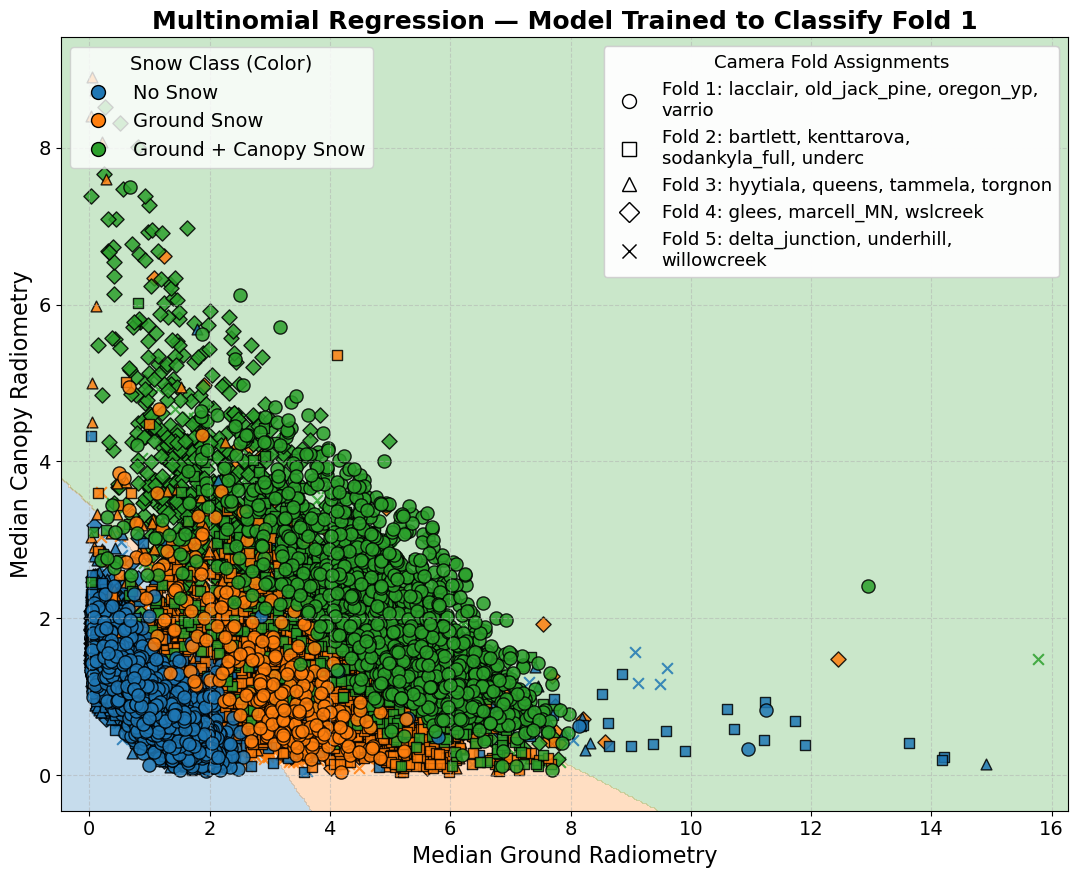

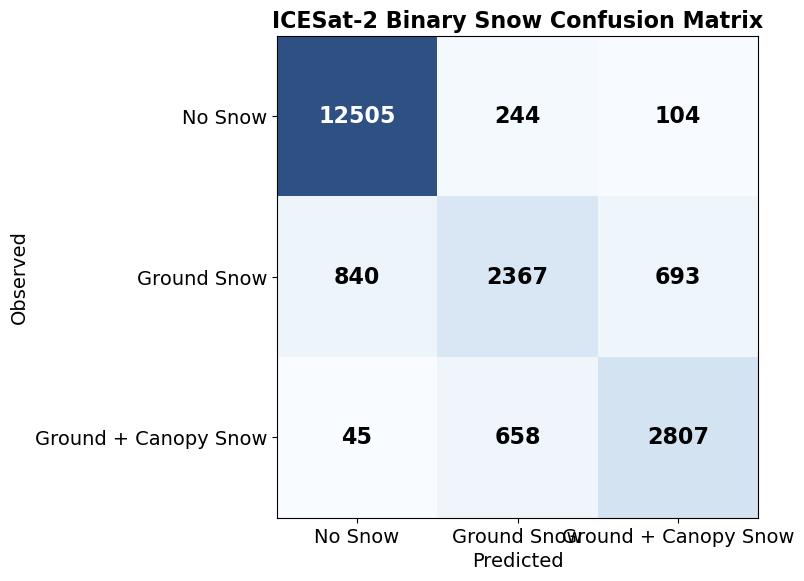

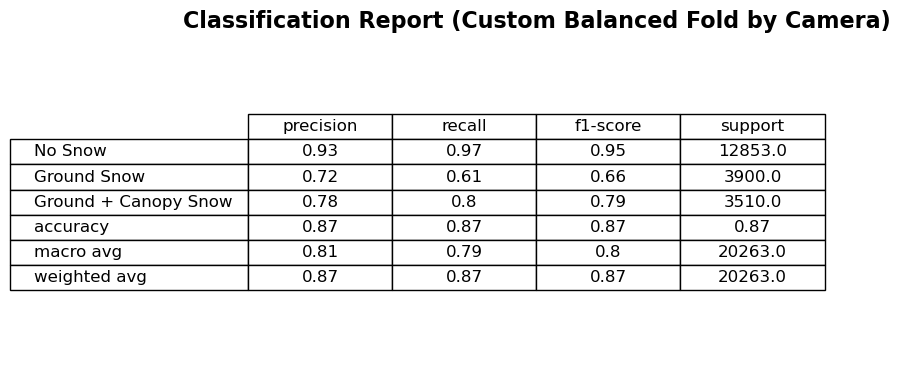

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from textwrap import fill

# --- Prepare Data ---
data['JointSnowRounded'] = data['JointSnow'].round().astype(int)

features = ['Eg_strong', 'Ev_strong']
target = 'JointSnowRounded'

X = data[features].values
y = data[target].values


# --- Create Custom Balanced GroupKFold on "camera" ---
n_splits = 5

camera_counts = data['camera'].value_counts()
sorted_cameras = camera_counts.index.tolist()

camera_to_fold = {}

for i, cam in enumerate(sorted_cameras):
    camera_to_fold[cam] = i % n_splits

group_indices = data['camera'].map(camera_to_fold).values


# --- Containers / styling ---
labels_str = [
    'No Snow',
    'Ground Snow',
    'Ground + Canopy Snow'
]

class_colors = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c'   # Green
]

group_markers = [
    'o',
    's',
    '^',
    'D',
    'x'
]

all_y_true = []
all_y_pred = []


# Keep fold -> cameras for legend block
fold_to_cameras = {
    f: []
    for f in range(n_splits)
}

for cam, f in camera_to_fold.items():
    fold_to_cameras[f].append(cam)


# --- Cross-validation to gather overall metrics ---
for fold_idx in range(n_splits):

    test_idx = np.where(group_indices == fold_idx)[0]
    train_idx = np.where(group_indices != fold_idx)[0]

    cv_model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=42,
        penalty=None
    )

    cv_model.fit(
        X[train_idx],
        y[train_idx]
    )

    y_pred = cv_model.predict(
        X[test_idx]
    )

    all_y_true.extend(
        y[test_idx]
    )

    all_y_pred.extend(
        y_pred
    )


# === Train the final model specifically for predicting Fold 1 (index 0) ===
first_fold = 0

first_test_idx = np.where(
    group_indices == first_fold
)[0]

first_train_idx = np.where(
    group_indices != first_fold
)[0]

final_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    penalty=None
)

final_model.fit(
    X[first_train_idx],
    y[first_train_idx]
)


# --- Mesh for decision boundary using the Fold 1 model ---
x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5

y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

Z = final_model.predict(
    grid
).reshape(xx.shape)


# ============================================================
# Plot decision boundaries and all folds
# ============================================================

plt.rcParams.update({
    'font.size': 14
})

fig, ax = plt.subplots(
    figsize=(11, 9)
)


# Decision boundary background from the Fold 1 model
ax.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    levels=[
        -0.5,
        0.5,
        1.5,
        2.5
    ],
    colors=class_colors
)


# Overlay all data
# Fold 1 is still slightly larger, but no longer outlined in red
for fold in [4, 3, 2, 1, 0]:

    for cls in [0, 1, 2]:

        mask = (
            (group_indices == fold)
            & (y == cls)
        )

        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            color=class_colors[cls],
            marker=group_markers[fold],
            edgecolor='k',
            s=60 if fold != first_fold else 90,
            alpha=0.85
        )


# --- Class legend: color ---
class_handles = [
    plt.Line2D(
        [0],
        [0],
        marker='o',
        linestyle='',
        markerfacecolor=class_colors[i],
        markeredgecolor='k',
        markersize=10
    )
    for i in range(3)
]

class_legend = ax.legend(
    class_handles,
    labels_str,
    title='Snow Class (Color)',
    loc='upper left',
    frameon=True
)

ax.add_artist(
    class_legend
)


# --- Combined Fold marker + camera list block in top right ---
fold_handles = []
fold_labels = []

wrap_width = 44

for f in range(n_splits):

    handle = plt.Line2D(
        [0],
        [0],
        marker=group_markers[f],
        linestyle='',
        markerfacecolor='white',
        markeredgecolor='k',
        markersize=10
    )

    cams = sorted(
        fold_to_cameras[f]
    )

    cams_text = (
        ", ".join(cams)
        if cams
        else "(no cameras)"
    )

    label = (
        f"Fold {f + 1}: "
        f"{cams_text}"
    )

    fold_handles.append(
        handle
    )

    fold_labels.append(
        fill(
            label,
            width=wrap_width
        )
    )


fold_legend = ax.legend(
    fold_handles,
    fold_labels,
    title='Camera Fold Assignments',
    loc='upper right',
    frameon=True,
    fontsize=13,
    title_fontsize=13
)

ax.add_artist(
    fold_legend
)


# --- Axis labels and title ---
ax.set_xlabel(
    'Median Ground Radiometry',
    fontsize=16
)

ax.set_ylabel(
    'Median Canopy Radiometry',
    fontsize=16
)

ax.set_title(
    'Multinomial Regression — Model Trained to Classify Fold 1',
    fontsize=18,
    weight='bold'
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

# plt.savefig(
#     './images/600dpi/fold_example.png',
#     dpi=600,
#     bbox_inches='tight'
# )


# ============================================================
# Confusion Matrix: all folds
# ============================================================

cm = confusion_matrix(
    all_y_true,
    all_y_pred
)

fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    cm,
    cmap='Blues',
    alpha=0.85
)


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            fontsize=16,
            fontweight='bold',
            color=(
                'white'
                if cm[i, j] > cm.max() / 2
                else 'black'
            )
        )


ax.set_xticks(
    np.arange(3)
)

ax.set_yticks(
    np.arange(3)
)

ax.set_xticklabels(
    labels_str,
    fontsize=14
)

ax.set_yticklabels(
    labels_str,
    fontsize=14
)

ax.set_xlabel(
    'Predicted',
    fontsize=14
)

ax.set_ylabel(
    'Observed',
    fontsize=14
)

ax.set_title(
    'ICESat-2 Binary Snow Confusion Matrix',
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()


# ============================================================
# Classification Report: all folds
# ============================================================

report_dict = classification_report(
    all_y_true,
    all_y_pred,
    target_names=labels_str,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose().round(2)


fig, ax = plt.subplots(
    figsize=(9, 4)
)

ax.axis('off')


table = ax.table(
    cellText=report_df.values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(
    False
)

table.set_fontsize(
    12
)

table.scale(
    1.2,
    1.4
)

plt.title(
    'Classification Report (Custom Balanced Fold by Camera)',
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()

Observations: 21,089
Cameras: 18
Requested bootstrap fits: 1000
Completed bootstrap fits: 1000

Individual bootstrap OOB three-class accuracy:
Median: 86.8%
95% bootstrap interval: 79.0%–93.8%

OOB predictions received per observation:
Minimum: 342
Median: 362
Maximum: 377


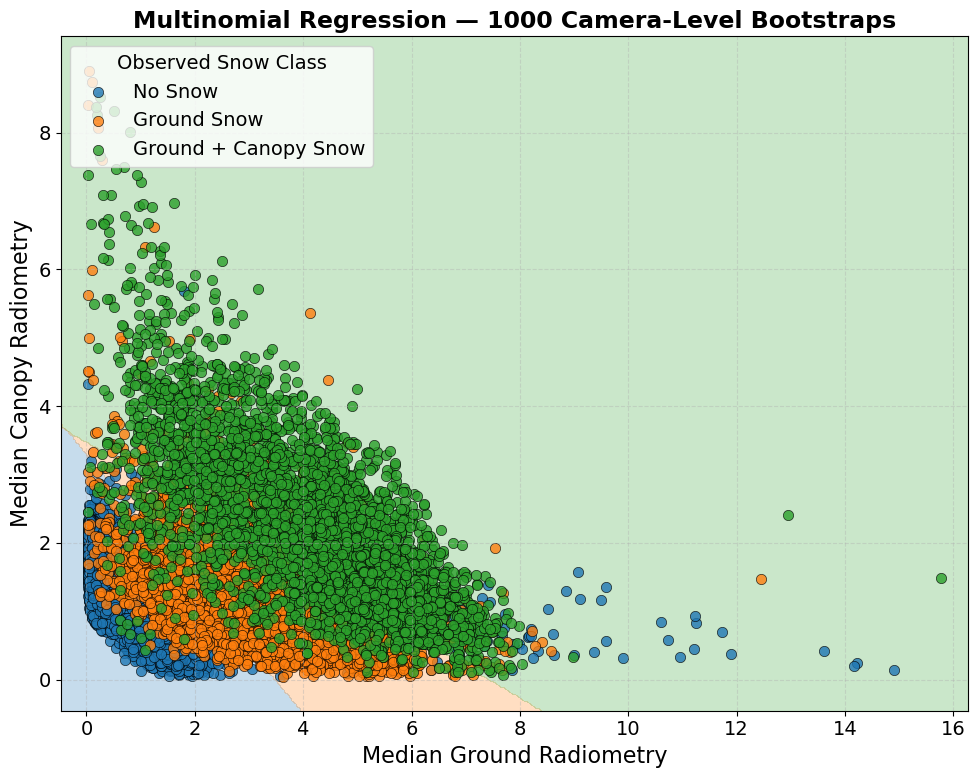

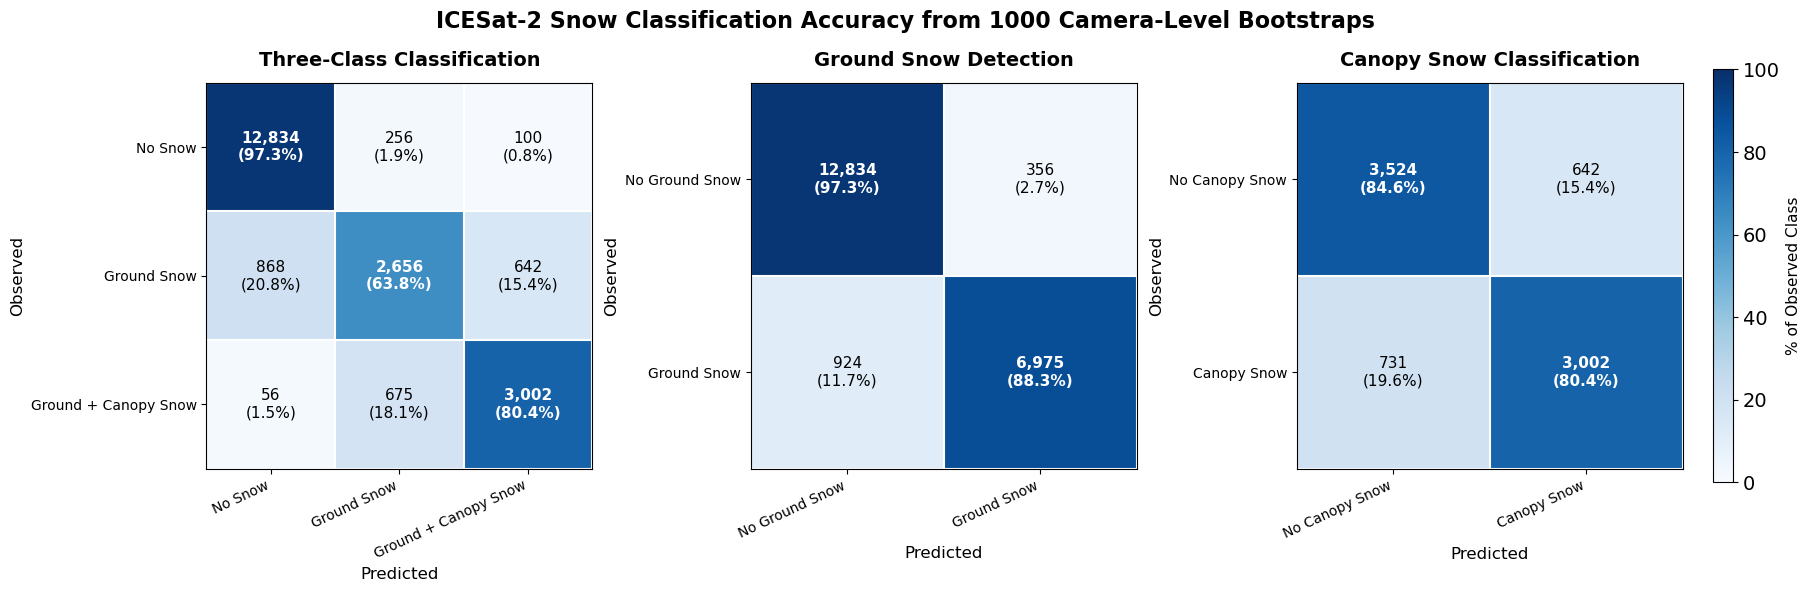

,precision,recall,f1-score,support
No Snow,0.933,0.973,0.953,13190.000
Ground Snow,0.740,0.638,0.685,4166.000
Ground + Canopy Snow,0.802,0.804,0.803,3733.000
accuracy,0.877,0.877,0.877,0.877
macro avg,0.825,0.805,0.814,21089.000
weighted avg,0.872,0.877,0.873,21089.000


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


# ============================================================
# SETTINGS
# ============================================================

N_BOOTSTRAPS = 1000
RANDOM_SEED = 42

features = [
    'Eg_strong',
    'Ev_strong'
]

target = 'JointSnowRounded'

labels_str = [
    'No Snow',
    'Ground Snow',
    'Ground + Canopy Snow'
]

class_colors = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c'   # Green
]


# ============================================================
# PREPARE DATA
# ============================================================

data = data.copy()

# Remove rows that cannot be used before converting the target
data = data.dropna(
    subset=[
        'JointSnow',
        'camera',
        *features
    ]
).copy()

data[target] = (
    data['JointSnow']
    .round()
    .astype(int)
)

# Only retain the three intended classes
data = data[
    data[target].isin([0, 1, 2])
].copy()

data.reset_index(
    drop=True,
    inplace=True
)

X = data[features].to_numpy()
y = data[target].to_numpy()
camera_values = data['camera'].to_numpy()

unique_cameras = pd.unique(
    camera_values
)

n_cameras = len(
    unique_cameras
)

if n_cameras < 3:
    raise ValueError(
        "At least three cameras are required for camera-level "
        "bootstrap fitting and out-of-bag testing."
    )

print(f"Observations: {len(data):,}")
print(f"Cameras: {n_cameras}")
print(f"Requested bootstrap fits: {N_BOOTSTRAPS}")


# Store the row indices belonging to each camera
camera_row_indices = {
    camera: np.flatnonzero(
        camera_values == camera
    )
    for camera in unique_cameras
}


# ============================================================
# CAMERA-LEVEL BOOTSTRAPPING
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

# Sum of out-of-bag predicted probabilities for each observation
oob_probability_sum = np.zeros(
    (len(data), 3),
    dtype=float
)

# Number of models for which each observation was out-of-bag
oob_prediction_count = np.zeros(
    len(data),
    dtype=int
)

bootstrap_models = []
bootstrap_accuracies = []
bootstrap_oob_cameras = []

completed_bootstraps = 0
attempts = 0
max_attempts = N_BOOTSTRAPS * 100


while (
    completed_bootstraps < N_BOOTSTRAPS
    and attempts < max_attempts
):

    attempts += 1

    # Sample cameras with replacement
    sampled_cameras = rng.choice(
        unique_cameras,
        size=n_cameras,
        replace=True
    )

    sampled_camera_set = set(
        sampled_cameras.tolist()
    )

    # Cameras not selected are the out-of-bag test cameras
    oob_cameras = [
        camera
        for camera in unique_cameras
        if camera not in sampled_camera_set
    ]

    # Occasionally every camera may be selected at least once
    if len(oob_cameras) == 0:
        continue

    # Repeatedly sampled cameras contribute their observations
    # repeatedly to the bootstrap training sample
    train_idx = np.concatenate([
        camera_row_indices[camera]
        for camera in sampled_cameras
    ])

    test_idx = np.concatenate([
        camera_row_indices[camera]
        for camera in oob_cameras
    ])

    # Multinomial regression requires all three classes
    if len(np.unique(y[train_idx])) < 3:
        continue

    if len(test_idx) == 0:
        continue

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED + completed_bootstraps,
        penalty=None
    )

    model.fit(
        X[train_idx],
        y[train_idx]
    )

    # Out-of-bag classification
    test_probabilities = model.predict_proba(
        X[test_idx]
    )

    test_predictions = model.predict(
        X[test_idx]
    )

    # Add probabilities to the appropriate class columns
    for probability_column, class_value in enumerate(
        model.classes_
    ):
        oob_probability_sum[
            test_idx,
            int(class_value)
        ] += test_probabilities[
            :,
            probability_column
        ]

    oob_prediction_count[test_idx] += 1

    bootstrap_accuracies.append(
        np.mean(
            test_predictions == y[test_idx]
        )
    )

    bootstrap_models.append(
        model
    )

    bootstrap_oob_cameras.append(
        oob_cameras
    )

    completed_bootstraps += 1


if completed_bootstraps < N_BOOTSTRAPS:
    raise RuntimeError(
        f"Only {completed_bootstraps} valid bootstrap fits could "
        f"be generated after {attempts} attempts."
    )

print(
    f"Completed bootstrap fits: "
    f"{completed_bootstraps}"
)


# ============================================================
# COMBINE OUT-OF-BAG PREDICTIONS
# ============================================================

# Normally every observation will receive many OOB predictions.
# This mask protects against the unlikely case that a camera was
# included in every bootstrap training sample.
has_oob_prediction = (
    oob_prediction_count > 0
)

if not np.all(has_oob_prediction):

    missing_count = np.sum(
        ~has_oob_prediction
    )

    print(
        f"Warning: {missing_count:,} observations received no "
        f"out-of-bag prediction and will be excluded."
    )


mean_oob_probability = np.divide(
    oob_probability_sum[has_oob_prediction],
    oob_prediction_count[
        has_oob_prediction,
        np.newaxis
    ],
    out=np.zeros_like(
        oob_probability_sum[has_oob_prediction]
    ),
    where=(
        oob_prediction_count[
            has_oob_prediction,
            np.newaxis
        ] != 0
    )
)

y_true = y[
    has_oob_prediction
]

# Final class is the class with the highest mean OOB probability
y_pred = np.argmax(
    mean_oob_probability,
    axis=1
)


# ============================================================
# BOOTSTRAP SUMMARY
# ============================================================

bootstrap_accuracies = np.asarray(
    bootstrap_accuracies
)

accuracy_lower, accuracy_upper = np.percentile(
    bootstrap_accuracies,
    [2.5, 97.5]
)

print(
    "\nIndividual bootstrap OOB three-class accuracy:"
)

print(
    f"Median: "
    f"{np.median(bootstrap_accuracies) * 100:.1f}%"
)

print(
    f"95% bootstrap interval: "
    f"{accuracy_lower * 100:.1f}%–"
    f"{accuracy_upper * 100:.1f}%"
)

print(
    "\nOOB predictions received per observation:"
)

print(
    f"Minimum: {oob_prediction_count[has_oob_prediction].min()}"
)

print(
    f"Median: "
    f"{np.median(oob_prediction_count[has_oob_prediction]):.0f}"
)

print(
    f"Maximum: {oob_prediction_count[has_oob_prediction].max()}"
)


# ============================================================
# OPTIONAL: BOOTSTRAP-ENSEMBLE DECISION BOUNDARY
# ============================================================

x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5

y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])

ensemble_grid_probability = np.zeros(
    (len(grid), 3),
    dtype=float
)

for model in bootstrap_models:

    model_probability = model.predict_proba(
        grid
    )

    for probability_column, class_value in enumerate(
        model.classes_
    ):
        ensemble_grid_probability[
            :,
            int(class_value)
        ] += model_probability[
            :,
            probability_column
        ]

ensemble_grid_probability /= len(
    bootstrap_models
)

Z = np.argmax(
    ensemble_grid_probability,
    axis=1
).reshape(xx.shape)


plt.rcParams.update({
    'font.size': 14
})

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    levels=[
        -0.5,
        0.5,
        1.5,
        2.5
    ],
    colors=class_colors
)

for class_value in [0, 1, 2]:

    class_mask = (
        y == class_value
    )

    ax.scatter(
        X[class_mask, 0],
        X[class_mask, 1],
        color=class_colors[class_value],
        marker='o',
        edgecolor='black',
        linewidth=0.5,
        s=55,
        alpha=0.80,
        label=labels_str[class_value]
    )

ax.set_xlabel(
    'Median Ground Radiometry',
    fontsize=16
)

ax.set_ylabel(
    'Median Canopy Radiometry',
    fontsize=16
)

ax.set_title(
    f'Multinomial Regression — {N_BOOTSTRAPS} Camera-Level Bootstraps',
    fontsize=17,
    weight='bold'
)

ax.legend(
    title='Observed Snow Class',
    loc='upper left',
    frameon=True
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# BUILD THE THREE CONFUSION MATRICES
# ============================================================

# ------------------------------------------------------------
# 1. Full three-class confusion matrix
# ------------------------------------------------------------

cm_three_class = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2]
)


# ------------------------------------------------------------
# 2. Ground snow detection
#
# Observed:
#   Class 0     -> no ground snow
#   Classes 1/2 -> ground snow
#
# Predicted:
#   Class 0     -> no ground snow detected
#   Classes 1/2 -> ground snow detected
# ------------------------------------------------------------

ground_true = (
    y_true > 0
).astype(int)

ground_pred = (
    y_pred > 0
).astype(int)

cm_ground = confusion_matrix(
    ground_true,
    ground_pred,
    labels=[0, 1]
)


# ------------------------------------------------------------
# 3. Canopy snow classification
#
# Only observations where ground snow is present are retained:
#   Observed class 1 -> no canopy snow
#   Observed class 2 -> canopy snow
#
# Any predicted class other than class 2 is treated as not
# detecting canopy snow. Therefore, a prediction of class 0 for
# a ground-snow observation also counts as "no canopy snow
# detected".
# ------------------------------------------------------------

observed_ground_snow_mask = (
    y_true > 0
)

canopy_true = (
    y_true[observed_ground_snow_mask] == 2
).astype(int)

canopy_pred = (
    y_pred[observed_ground_snow_mask] == 2
).astype(int)

cm_canopy = confusion_matrix(
    canopy_true,
    canopy_pred,
    labels=[0, 1]
)


# ============================================================
# PLOT CONFUSION MATRICES
# ============================================================

confusion_matrix_information = [
    {
        'title': 'Three-Class Classification',
        'matrix': cm_three_class,
        'classes': [
            'No Snow',
            'Ground Snow',
            'Ground + Canopy Snow'
        ]
    },
    {
        'title': 'Ground Snow Detection',
        'matrix': cm_ground,
        'classes': [
            'No Ground Snow',
            'Ground Snow'
        ]
    },
    {
        'title': (
            'Canopy Snow Classification'
        ),
        'matrix': cm_canopy,
        'classes': [
            'No Canopy Snow',
            'Canopy Snow'
        ]
    }
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.8),
    constrained_layout=True
)


for ax, matrix_information in zip(
    axes,
    confusion_matrix_information
):

    cm = matrix_information['matrix']
    classes = matrix_information['classes']
    title = matrix_information['title']

    # Row-normalised percentages
    row_totals = cm.sum(
        axis=1,
        keepdims=True
    )

    row_pct = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(
            cm,
            dtype=float
        ),
        where=row_totals != 0
    ) * 100

    im = ax.imshow(
        row_pct,
        cmap='Blues',
        vmin=0,
        vmax=100
    )

    ax.set_title(
        title,
        fontsize=14,
        weight='bold',
        pad=12
    )

    ax.set_xlabel(
        'Predicted',
        fontsize=12
    )

    ax.set_ylabel(
        'Observed',
        fontsize=12
    )

    ax.set_xticks(
        np.arange(len(classes))
    )

    ax.set_yticks(
        np.arange(len(classes))
    )

    ax.set_xticklabels(
        classes,
        rotation=25,
        ha='right',
        fontsize=10
    )

    ax.set_yticklabels(
        classes,
        fontsize=10
    )

    # Cell annotations: count and row percentage
    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            text_colour = (
                'white'
                if row_pct[i, j] > 50
                else 'black'
            )

            text_weight = (
                'bold'
                if i == j
                else 'normal'
            )

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}\n"
                f"({row_pct[i, j]:.1f}%)",
                ha='center',
                va='center',
                color=text_colour,
                fontsize=11,
                weight=text_weight
            )

    # White borders between cells
    ax.set_xticks(
        np.arange(
            -0.5,
            len(classes),
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(classes),
            1
        ),
        minor=True
    )

    ax.grid(
        which='minor',
        color='white',
        linewidth=1.5
    )

    ax.tick_params(
        which='minor',
        bottom=False,
        left=False
    )


cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.88,
    pad=0.02
)

cbar.set_label(
    '% of Observed Class',
    fontsize=11
)

fig.suptitle(
    'ICESat-2 Snow Classification Accuracy from '
    f'{N_BOOTSTRAPS} Camera-Level Bootstraps',
    fontsize=16,
    weight='bold'
)

plt.show()

# fig.savefig(
#     './images/600dpi/bootstrap_confusion_matrices.png',
#     dpi=600,
#     bbox_inches='tight'
# )


# ============================================================
# THREE-CLASS CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=labels_str,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose().round(3)

display(report_df)

Observations: 21,089
Cameras: 18
Requested bootstrap fits: 1000
Completed bootstrap fits: 1000
Pooled out-of-bag classification events: 7,656,185
Mean classifications per original observation: 363.0

Individual bootstrap OOB three-class accuracy:
Median: 86.8%
95% bootstrap interval: 79.0%–93.8%

OOB predictions received per observation:
Minimum: 342
Median: 362
Maximum: 377


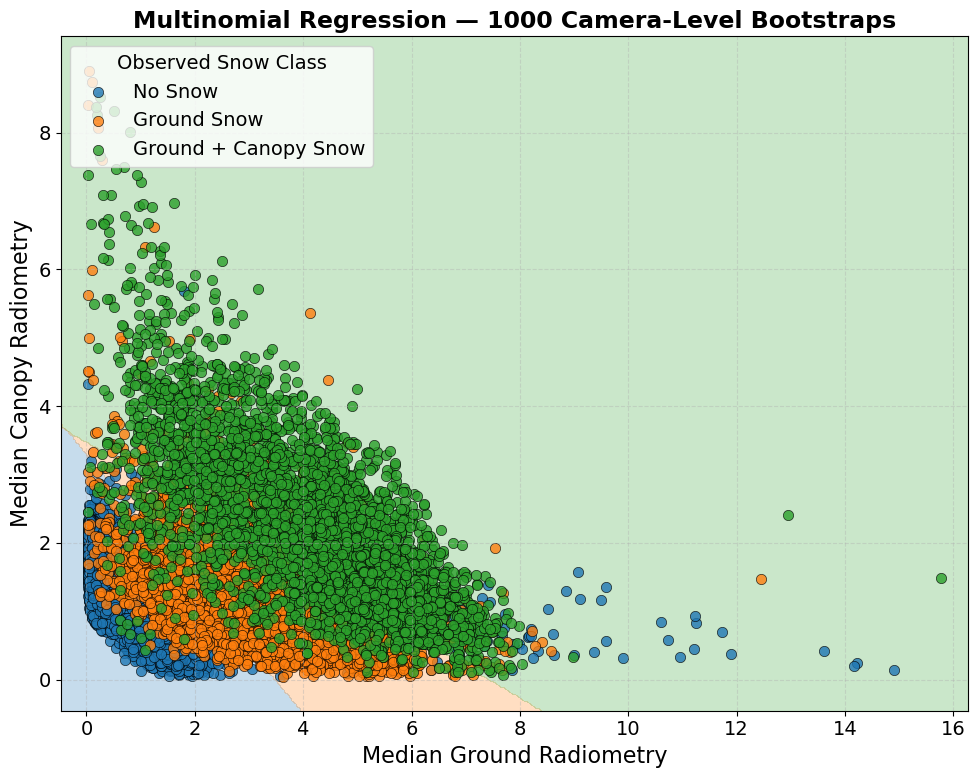

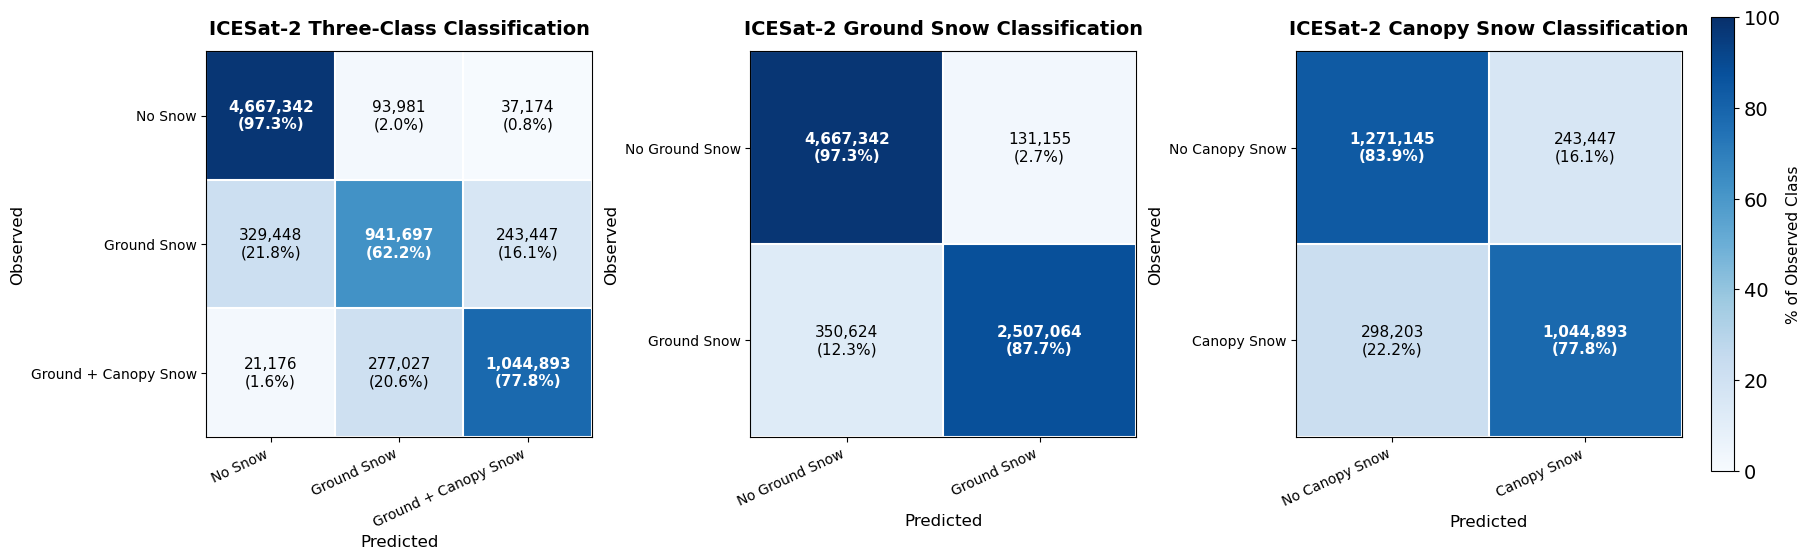

,precision,recall,f1-score,support
No Snow,0.930,0.973,0.951,4798497.000
Ground Snow,0.717,0.622,0.666,1514592.000
Ground + Canopy Snow,0.788,0.778,0.783,1343096.000
accuracy,0.869,0.869,0.869,0.869
macro avg,0.812,0.791,0.800,7656185.000
weighted avg,0.863,0.869,0.865,7656185.000


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


# ============================================================
# SETTINGS
# ============================================================

N_BOOTSTRAPS = 1000
RANDOM_SEED = 42

features = [
    'Eg_strong',
    'Ev_strong'
]

target = 'JointSnowRounded'

labels_str = [
    'No Snow',
    'Ground Snow',
    'Ground + Canopy Snow'
]

class_colors = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c'   # Green
]


# ============================================================
# PREPARE DATA
# ============================================================

data = data.copy()

# Remove rows that cannot be used before converting the target
data = data.dropna(
    subset=[
        'JointSnow',
        'camera',
        *features
    ]
).copy()

data[target] = (
    data['JointSnow']
    .round()
    .astype(int)
)

# Only retain the three intended classes
data = data[
    data[target].isin([0, 1, 2])
].copy()

data.reset_index(
    drop=True,
    inplace=True
)

X = data[features].to_numpy()
y = data[target].to_numpy()
camera_values = data['camera'].to_numpy()

unique_cameras = pd.unique(
    camera_values
)

n_cameras = len(
    unique_cameras
)

if n_cameras < 3:
    raise ValueError(
        "At least three cameras are required for camera-level "
        "bootstrap fitting and out-of-bag testing."
    )

print(f"Observations: {len(data):,}")
print(f"Cameras: {n_cameras}")
print(f"Requested bootstrap fits: {N_BOOTSTRAPS}")


# Store the row indices belonging to each camera
camera_row_indices = {
    camera: np.flatnonzero(
        camera_values == camera
    )
    for camera in unique_cameras
}


# ============================================================
# CAMERA-LEVEL BOOTSTRAPPING
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

# Pool every out-of-bag classification from every bootstrap.
# An observation is therefore included once for each bootstrap
# in which its camera is out-of-bag.
all_y_true = []
all_y_pred = []

# Number of models for which each observation was out-of-bag
oob_prediction_count = np.zeros(
    len(data),
    dtype=int
)

bootstrap_models = []
bootstrap_accuracies = []
bootstrap_oob_cameras = []

completed_bootstraps = 0
attempts = 0
max_attempts = N_BOOTSTRAPS * 100


while (
    completed_bootstraps < N_BOOTSTRAPS
    and attempts < max_attempts
):

    attempts += 1

    # Sample cameras with replacement
    sampled_cameras = rng.choice(
        unique_cameras,
        size=n_cameras,
        replace=True
    )

    sampled_camera_set = set(
        sampled_cameras.tolist()
    )

    # Cameras not selected are the out-of-bag test cameras
    oob_cameras = [
        camera
        for camera in unique_cameras
        if camera not in sampled_camera_set
    ]

    # Occasionally every camera may be selected at least once
    if len(oob_cameras) == 0:
        continue

    # Repeatedly sampled cameras contribute their observations
    # repeatedly to the bootstrap training sample
    train_idx = np.concatenate([
        camera_row_indices[camera]
        for camera in sampled_cameras
    ])

    test_idx = np.concatenate([
        camera_row_indices[camera]
        for camera in oob_cameras
    ])

    # Multinomial regression requires all three classes
    if len(np.unique(y[train_idx])) < 3:
        continue

    if len(test_idx) == 0:
        continue

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED + completed_bootstraps,
        penalty=None
    )

    model.fit(
        X[train_idx],
        y[train_idx]
    )

    # Out-of-bag classification
    test_predictions = model.predict(
        X[test_idx]
    )

    # Retain every classification event. The same observation can
    # appear in several bootstraps, but only when it is out-of-bag.
    all_y_true.append(
        y[test_idx].copy()
    )

    all_y_pred.append(
        test_predictions.copy()
    )

    oob_prediction_count[test_idx] += 1

    bootstrap_accuracies.append(
        np.mean(
            test_predictions == y[test_idx]
        )
    )

    bootstrap_models.append(
        model
    )

    bootstrap_oob_cameras.append(
        oob_cameras
    )

    completed_bootstraps += 1


if completed_bootstraps < N_BOOTSTRAPS:
    raise RuntimeError(
        f"Only {completed_bootstraps} valid bootstrap fits could "
        f"be generated after {attempts} attempts."
    )

print(
    f"Completed bootstrap fits: "
    f"{completed_bootstraps}"
)


# ============================================================
# POOL ALL OUT-OF-BAG CLASSIFICATIONS
# ============================================================

y_true = np.concatenate(
    all_y_true
)

y_pred = np.concatenate(
    all_y_pred
)

print(
    f"Pooled out-of-bag classification events: "
    f"{len(y_true):,}"
)

print(
    f"Mean classifications per original observation: "
    f"{len(y_true) / len(data):.1f}"
)


# ============================================================
# BOOTSTRAP SUMMARY
# ============================================================

bootstrap_accuracies = np.asarray(
    bootstrap_accuracies
)

accuracy_lower, accuracy_upper = np.percentile(
    bootstrap_accuracies,
    [2.5, 97.5]
)

print(
    "\nIndividual bootstrap OOB three-class accuracy:"
)

print(
    f"Median: "
    f"{np.median(bootstrap_accuracies) * 100:.1f}%"
)

print(
    f"95% bootstrap interval: "
    f"{accuracy_lower * 100:.1f}%–"
    f"{accuracy_upper * 100:.1f}%"
)

print(
    "\nOOB predictions received per observation:"
)

observations_with_oob_predictions = (
    oob_prediction_count > 0
)

if not np.all(observations_with_oob_predictions):

    missing_count = np.sum(
        ~observations_with_oob_predictions
    )

    print(
        f"Warning: {missing_count:,} observations received no "
        f"out-of-bag classifications."
    )

print(
    f"Minimum: {oob_prediction_count.min()}"
)

print(
    f"Median: "
    f"{np.median(oob_prediction_count):.0f}"
)

print(
    f"Maximum: {oob_prediction_count.max()}"
)


# ============================================================
# OPTIONAL: BOOTSTRAP-ENSEMBLE DECISION BOUNDARY
# ============================================================

x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5

y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])

ensemble_grid_probability = np.zeros(
    (len(grid), 3),
    dtype=float
)

for model in bootstrap_models:

    model_probability = model.predict_proba(
        grid
    )

    for probability_column, class_value in enumerate(
        model.classes_
    ):
        ensemble_grid_probability[
            :,
            int(class_value)
        ] += model_probability[
            :,
            probability_column
        ]

ensemble_grid_probability /= len(
    bootstrap_models
)

Z = np.argmax(
    ensemble_grid_probability,
    axis=1
).reshape(xx.shape)


plt.rcParams.update({
    'font.size': 14
})

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.contourf(
    xx,
    yy,
    Z,
    alpha=0.25,
    levels=[
        -0.5,
        0.5,
        1.5,
        2.5
    ],
    colors=class_colors
)

for class_value in [0, 1, 2]:

    class_mask = (
        y == class_value
    )

    ax.scatter(
        X[class_mask, 0],
        X[class_mask, 1],
        color=class_colors[class_value],
        marker='o',
        edgecolor='black',
        linewidth=0.5,
        s=55,
        alpha=0.80,
        label=labels_str[class_value]
    )

ax.set_xlabel(
    'Median Ground Radiometry',
    fontsize=16
)

ax.set_ylabel(
    'Median Canopy Radiometry',
    fontsize=16
)

ax.set_title(
    f'Multinomial Regression — {N_BOOTSTRAPS} Camera-Level Bootstraps',
    fontsize=17,
    weight='bold'
)

ax.legend(
    title='Observed Snow Class',
    loc='upper left',
    frameon=True
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# BUILD THE THREE CONFUSION MATRICES
# ============================================================

# ------------------------------------------------------------
# 1. Full three-class confusion matrix
# ------------------------------------------------------------

cm_three_class = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2]
)


# ------------------------------------------------------------
# 2. Ground snow detection
#
# Observed:
#   Class 0     -> no ground snow
#   Classes 1/2 -> ground snow
#
# Predicted:
#   Class 0     -> no ground snow detected
#   Classes 1/2 -> ground snow detected
# ------------------------------------------------------------

ground_true = (
    y_true > 0
).astype(int)

ground_pred = (
    y_pred > 0
).astype(int)

cm_ground = confusion_matrix(
    ground_true,
    ground_pred,
    labels=[0, 1]
)


# ------------------------------------------------------------
# 3. Canopy snow classification
#
# Only observations where ground snow is present are retained:
#   Observed class 1 -> no canopy snow
#   Observed class 2 -> canopy snow
#
# Any predicted class other than class 2 is treated as not
# detecting canopy snow. Therefore, a prediction of class 0 for
# a ground-snow observation also counts as "no canopy snow
# detected".
# ------------------------------------------------------------

observed_ground_snow_mask = (
    y_true > 0
)

canopy_true = (
    y_true[observed_ground_snow_mask] == 2
).astype(int)

canopy_pred = (
    y_pred[observed_ground_snow_mask] == 2
).astype(int)

cm_canopy = confusion_matrix(
    canopy_true,
    canopy_pred,
    labels=[0, 1]
)


# ============================================================
# PLOT CONFUSION MATRICES
# ============================================================

confusion_matrix_information = [
    {
        'title': 'ICESat-2 Three Classes',
        'matrix': cm_three_class,
        'classes': [
            'No Snow',
            'Ground Snow',
            'Ground + Canopy Snow'
        ]
    },
    {
        'title': 'ICESat-2 Ground Snow',
        'matrix': cm_ground,
        'classes': [
            'No Ground Snow',
            'Ground Snow'
        ]
    },
    {
        'title': (
            'ICESat-2 Canopy Snow'
        ),
        'matrix': cm_canopy,
        'classes': [
            'No Canopy Snow',
            'Canopy Snow'
        ]
    }
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.8),
    constrained_layout=True
)


for ax, matrix_information in zip(
    axes,
    confusion_matrix_information
):

    cm = matrix_information['matrix']
    classes = matrix_information['classes']
    title = matrix_information['title']

    # Row-normalised percentages
    row_totals = cm.sum(
        axis=1,
        keepdims=True
    )

    row_pct = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(
            cm,
            dtype=float
        ),
        where=row_totals != 0
    ) * 100

    im = ax.imshow(
        row_pct,
        cmap='Blues',
        vmin=0,
        vmax=100
    )

    ax.set_title(
        title,
        fontsize=14,
        weight='bold',
        pad=12
    )

    ax.set_xlabel(
        'Predicted',
        fontsize=12
    )

    ax.set_ylabel(
        'Observed',
        fontsize=12
    )

    ax.set_xticks(
        np.arange(len(classes))
    )

    ax.set_yticks(
        np.arange(len(classes))
    )

    ax.set_xticklabels(
        classes,
        rotation=25,
        ha='right',
        fontsize=10
    )

    ax.set_yticklabels(
        classes,
        fontsize=10
    )

    # Cell annotations: count and row percentage
    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            text_colour = (
                'white'
                if row_pct[i, j] > 50
                else 'black'
            )

            text_weight = (
                'bold'
                if i == j
                else 'normal'
            )

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}\n"
                f"({row_pct[i, j]:.1f}%)",
                ha='center',
                va='center',
                color=text_colour,
                fontsize=11,
                weight=text_weight
            )

    # White borders between cells
    ax.set_xticks(
        np.arange(
            -0.5,
            len(classes),
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(classes),
            1
        ),
        minor=True
    )

    ax.grid(
        which='minor',
        color='white',
        linewidth=1.5
    )

    ax.tick_params(
        which='minor',
        bottom=False,
        left=False
    )


cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.88,
    pad=0.02
)

cbar.set_label(
    '% of Observed Class',
    fontsize=11
)

# fig.suptitle(
#     'ICESat-2 Snow Classification Accuracy from '
#     f'{N_BOOTSTRAPS} Camera-Level Bootstraps',
#     fontsize=16,
#     weight='bold'
# )

plt.show()

# fig.savefig(
#     './images/600dpi/bootstrap_confusion_matrices.png',
#     dpi=600,
#     bbox_inches='tight'
# )


# ============================================================
# THREE-CLASS CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=labels_str,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose().round(3)

display(report_df)

Observations: 21,089
Cameras: 18
Requested bootstrap fits: 1000
Completed bootstrap fits: 1000
Pooled out-of-bag classification events: 7,656,185
Mean classifications per original observation: 363.0

Individual bootstrap OOB three-class accuracy:
Median: 86.8%
95% bootstrap interval: 79.0%93.8%

OOB predictions received per observation:
Minimum: 342
Median: 362
Maximum: 377


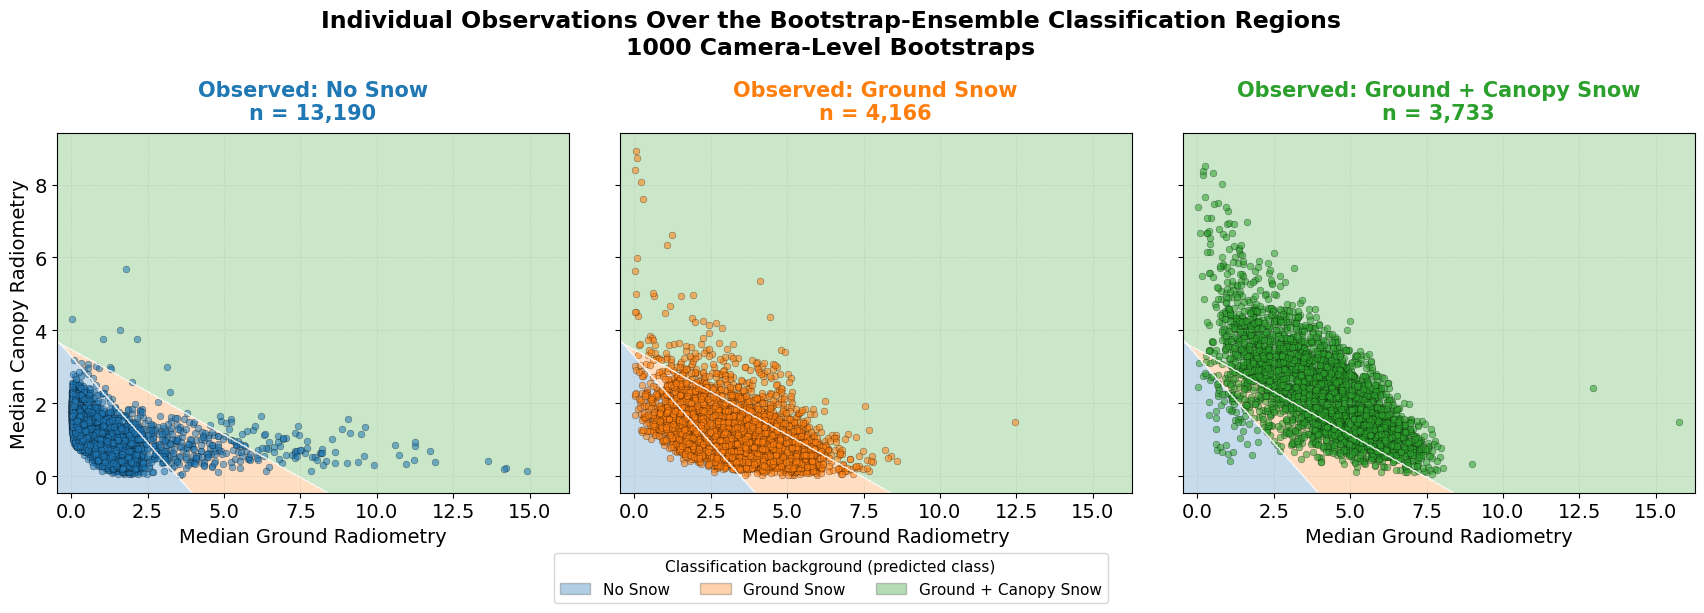

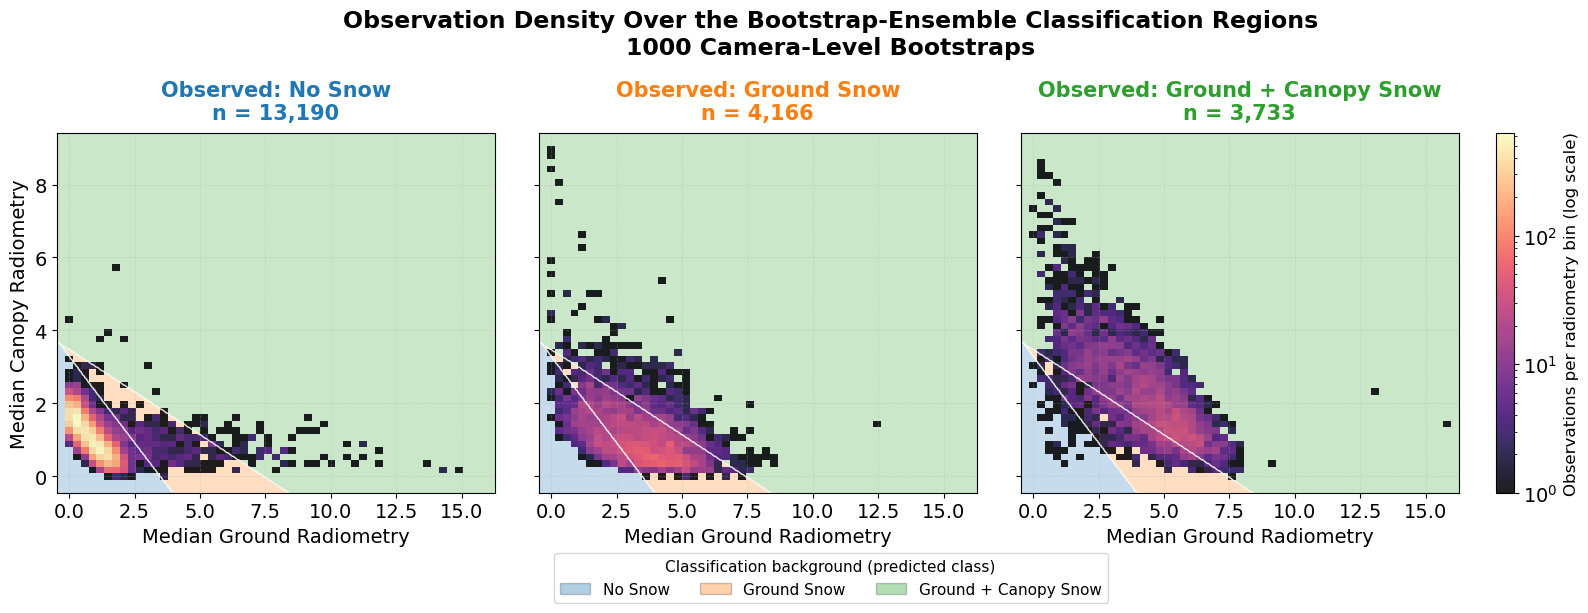

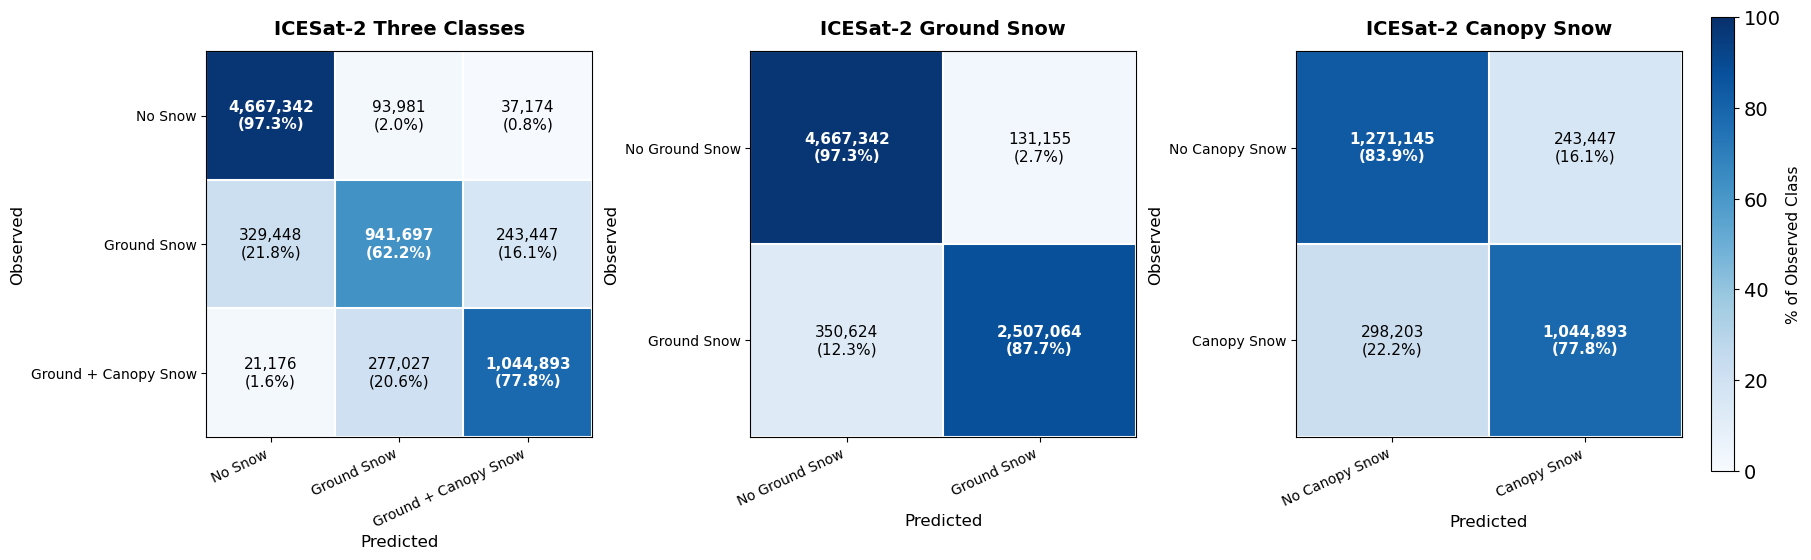

,precision,recall,f1-score,support
No Snow,0.930,0.973,0.951,4798497.000
Ground Snow,0.717,0.622,0.666,1514592.000
Ground + Canopy Snow,0.788,0.778,0.783,1343096.000
accuracy,0.869,0.869,0.869,0.869
macro avg,0.812,0.791,0.800,7656185.000
weighted avg,0.863,0.869,0.865,7656185.000


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


# ============================================================
# SETTINGS
# ============================================================

N_BOOTSTRAPS = 1000
RANDOM_SEED = 42

features = [
    'Eg_strong',
    'Ev_strong'
]

target = 'JointSnowRounded'

labels_str = [
    'No Snow',
    'Ground Snow',
    'Ground + Canopy Snow'
]

class_colors = [
    '#1f77b4',  # Blue
    '#ff7f0e',  # Orange
    '#2ca02c'   # Green
]

# How to display the observations over the classification background:
#   'points'  -> one scatter-plot figure
#   'density' -> one log-density figure
#   'both'    -> make both figures
OBSERVATION_PLOT_MODE = 'both'

POINT_SIZE = 24
POINT_ALPHA = 0.55
DENSITY_BINS = 55


# ============================================================
# PREPARE DATA
# ============================================================

data = data.copy()

# Remove rows that cannot be used before converting the target
data = data.dropna(
    subset=[
        'JointSnow',
        'camera',
        *features
    ]
).copy()

data[target] = (
    data['JointSnow']
    .round()
    .astype(int)
)

# Only retain the three intended classes
data = data[
    data[target].isin([0, 1, 2])
].copy()

data.reset_index(
    drop=True,
    inplace=True
)

X = data[features].to_numpy()
y = data[target].to_numpy()
camera_values = data['camera'].to_numpy()

unique_cameras = pd.unique(
    camera_values
)

n_cameras = len(
    unique_cameras
)

if n_cameras < 3:
    raise ValueError(
        "At least three cameras are required for camera-level "
        "bootstrap fitting and out-of-bag testing."
    )

print(f"Observations: {len(data):,}")
print(f"Cameras: {n_cameras}")
print(f"Requested bootstrap fits: {N_BOOTSTRAPS}")


# Store the row indices belonging to each camera
camera_row_indices = {
    camera: np.flatnonzero(
        camera_values == camera
    )
    for camera in unique_cameras
}


# ============================================================
# CAMERA-LEVEL BOOTSTRAPPING
# ============================================================

rng = np.random.default_rng(
    RANDOM_SEED
)

# Pool every out-of-bag classification from every bootstrap.
# An observation is therefore included once for each bootstrap
# in which its camera is out-of-bag.
all_y_true = []
all_y_pred = []

# Number of models for which each observation was out-of-bag
oob_prediction_count = np.zeros(
    len(data),
    dtype=int
)

bootstrap_models = []
bootstrap_accuracies = []
bootstrap_oob_cameras = []

completed_bootstraps = 0
attempts = 0
max_attempts = N_BOOTSTRAPS * 100


while (
    completed_bootstraps < N_BOOTSTRAPS
    and attempts < max_attempts
):

    attempts += 1

    # Sample cameras with replacement
    sampled_cameras = rng.choice(
        unique_cameras,
        size=n_cameras,
        replace=True
    )

    sampled_camera_set = set(
        sampled_cameras.tolist()
    )

    # Cameras not selected are the out-of-bag test cameras
    oob_cameras = [
        camera
        for camera in unique_cameras
        if camera not in sampled_camera_set
    ]

    # Occasionally every camera may be selected at least once
    if len(oob_cameras) == 0:
        continue

    # Repeatedly sampled cameras contribute their observations
    # repeatedly to the bootstrap training sample
    train_idx = np.concatenate([
        camera_row_indices[camera]
        for camera in sampled_cameras
    ])

    test_idx = np.concatenate([
        camera_row_indices[camera]
        for camera in oob_cameras
    ])

    # Multinomial regression requires all three classes
    if len(np.unique(y[train_idx])) < 3:
        continue

    if len(test_idx) == 0:
        continue

    model = LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_SEED + completed_bootstraps,
        penalty=None
    )

    model.fit(
        X[train_idx],
        y[train_idx]
    )

    # Out-of-bag classification
    test_predictions = model.predict(
        X[test_idx]
    )

    # Retain every classification event. The same observation can
    # appear in several bootstraps, but only when it is out-of-bag.
    all_y_true.append(
        y[test_idx].copy()
    )

    all_y_pred.append(
        test_predictions.copy()
    )

    oob_prediction_count[test_idx] += 1

    bootstrap_accuracies.append(
        np.mean(
            test_predictions == y[test_idx]
        )
    )

    bootstrap_models.append(
        model
    )

    bootstrap_oob_cameras.append(
        oob_cameras
    )

    completed_bootstraps += 1


if completed_bootstraps < N_BOOTSTRAPS:
    raise RuntimeError(
        f"Only {completed_bootstraps} valid bootstrap fits could "
        f"be generated after {attempts} attempts."
    )

print(
    f"Completed bootstrap fits: "
    f"{completed_bootstraps}"
)


# ============================================================
# POOL ALL OUT-OF-BAG CLASSIFICATIONS
# ============================================================

y_true = np.concatenate(
    all_y_true
)

y_pred = np.concatenate(
    all_y_pred
)

print(
    f"Pooled out-of-bag classification events: "
    f"{len(y_true):,}"
)

print(
    f"Mean classifications per original observation: "
    f"{len(y_true) / len(data):.1f}"
)


# ============================================================
# BOOTSTRAP SUMMARY
# ============================================================

bootstrap_accuracies = np.asarray(
    bootstrap_accuracies
)

accuracy_lower, accuracy_upper = np.percentile(
    bootstrap_accuracies,
    [2.5, 97.5]
)

print(
    "\nIndividual bootstrap OOB three-class accuracy:"
)

print(
    f"Median: "
    f"{np.median(bootstrap_accuracies) * 100:.1f}%"
)

print(
    f"95% bootstrap interval: "
    f"{accuracy_lower * 100:.1f}%"
    f"{accuracy_upper * 100:.1f}%"
)

print(
    "\nOOB predictions received per observation:"
)

observations_with_oob_predictions = (
    oob_prediction_count > 0
)

if not np.all(observations_with_oob_predictions):

    missing_count = np.sum(
        ~observations_with_oob_predictions
    )

    print(
        f"Warning: {missing_count:,} observations received no "
        f"out-of-bag classifications."
    )

print(
    f"Minimum: {oob_prediction_count.min()}"
)

print(
    f"Median: "
    f"{np.median(oob_prediction_count):.0f}"
)

print(
    f"Maximum: {oob_prediction_count.max()}"
)


# ============================================================
# BOOTSTRAP-ENSEMBLE CLASSIFICATION BACKGROUND
# ============================================================

x_min = X[:, 0].min() - 0.5
x_max = X[:, 0].max() + 0.5

y_min = X[:, 1].min() - 0.5
y_max = X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])

ensemble_grid_probability = np.zeros(
    (len(grid), 3),
    dtype=float
)

for model in bootstrap_models:

    model_probability = model.predict_proba(
        grid
    )

    for probability_column, class_value in enumerate(
        model.classes_
    ):
        ensemble_grid_probability[
            :,
            int(class_value)
        ] += model_probability[
            :,
            probability_column
        ]

ensemble_grid_probability /= len(
    bootstrap_models
)

Z = np.argmax(
    ensemble_grid_probability,
    axis=1
).reshape(xx.shape)


# ============================================================
# PLOT EACH OBSERVED CLASS SEPARATELY
# ============================================================

plt.rcParams.update({
    'font.size': 14
})

valid_observation_plot_modes = {
    'points',
    'density',
    'both'
}

if OBSERVATION_PLOT_MODE not in valid_observation_plot_modes:
    raise ValueError(
        "OBSERVATION_PLOT_MODE must be 'points', "
        "'density', or 'both'."
    )


classification_legend_handles = [
    Patch(
        facecolor=class_colors[class_value],
        edgecolor='0.35',
        label=labels_str[class_value],
        alpha=0.35
    )
    for class_value in [0, 1, 2]
]


def plot_observed_class_panels(display_mode):
    """
    Plot one panel for each observed snow class over the same
    bootstrap-ensemble classification background.

    Parameters
    ----------
    display_mode : {'points', 'density'}
        Whether observations are shown as individual points or
        as counts within a two-dimensional radiometry grid.
    """

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6.2),
        sharex=True,
        sharey=True
    )

    density_arrays = None
    density_norm = None

    if display_mode == 'density':

        density_arrays = []

        for class_value in [0, 1, 2]:

            class_mask = (
                y == class_value
            )

            density_count, x_edges, y_edges = np.histogram2d(
                X[class_mask, 0],
                X[class_mask, 1],
                bins=[
                    DENSITY_BINS,
                    DENSITY_BINS
                ],
                range=[
                    [x_min, x_max],
                    [y_min, y_max]
                ]
            )

            density_arrays.append(
                density_count
            )

        # Use one colour scale for all three panels so that the
        # observed densities can be compared directly.
        maximum_density = max(
            density_count.max()
            for density_count in density_arrays
        )

        density_norm = LogNorm(
            vmin=1,
            vmax=max(2, maximum_density)
        )

    density_mappable = None

    for class_value, ax in enumerate(axes):

        class_mask = (
            y == class_value
        )

        # Identical predicted-class background in every panel.
        ax.contourf(
            xx,
            yy,
            Z,
            alpha=0.25,
            levels=[
                -0.5,
                0.5,
                1.5,
                2.5
            ],
            colors=class_colors
        )

        # Make the boundaries between predicted classes easier
        # to distinguish beneath the observations.
        ax.contour(
            xx,
            yy,
            Z,
            levels=[
                0.5,
                1.5
            ],
            colors='white',
            linewidths=1.0,
            alpha=0.9
        )

        if display_mode == 'points':

            ax.scatter(
                X[class_mask, 0],
                X[class_mask, 1],
                color=class_colors[class_value],
                marker='o',
                edgecolor='black',
                linewidth=0.30,
                s=POINT_SIZE,
                alpha=POINT_ALPHA,
                rasterized=True
            )

        else:

            masked_density = np.ma.masked_where(
                density_arrays[class_value].T == 0,
                density_arrays[class_value].T
            )

            density_mappable = ax.pcolormesh(
                x_edges,
                y_edges,
                masked_density,
                cmap='magma',
                norm=density_norm,
                alpha=0.88,
                shading='auto',
                rasterized=True
            )

        ax.set_title(
            f'Observed: {labels_str[class_value]}\n'
            f'n = {class_mask.sum():,}',
            fontsize=15,
            weight='bold',
            color=class_colors[class_value],
            pad=10
        )

        ax.set_xlabel(
            'Median Ground Radiometry',
            fontsize=14
        )

        ax.set_xlim(
            x_min,
            x_max
        )

        ax.set_ylim(
            y_min,
            y_max
        )

        ax.grid(
            True,
            linestyle='--',
            linewidth=0.6,
            alpha=0.30
        )

    axes[0].set_ylabel(
        'Median Canopy Radiometry',
        fontsize=14
    )

    display_label = (
        'Individual Observations'
        if display_mode == 'points'
        else 'Observation Density'
    )

    fig.suptitle(
        f'{display_label} Over the Bootstrap-Ensemble '
        f'Classification Regions\n'
        f'{N_BOOTSTRAPS} Camera-Level Bootstraps',
        fontsize=17,
        weight='bold',
        y=0.98
    )

    if display_mode == 'density':

        fig.subplots_adjust(
            left=0.07,
            right=0.89,
            bottom=0.20,
            top=0.78,
            wspace=0.10
        )

        cbar = fig.colorbar(
            density_mappable,
            ax=axes,
            fraction=0.025,
            pad=0.025
        )

        cbar.set_label(
            'Observations per radiometry bin '
            '(log scale)',
            fontsize=12
        )

    else:

        fig.subplots_adjust(
            left=0.07,
            right=0.98,
            bottom=0.20,
            top=0.78,
            wspace=0.10
        )

    fig.legend(
        handles=classification_legend_handles,
        title='Classification background (predicted class)',
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        frameon=True,
        fontsize=11,
        title_fontsize=11
    )

    plt.show()

    return fig, axes


observation_figures = {}

if OBSERVATION_PLOT_MODE in {
    'points',
    'both'
}:

    point_figure, point_axes = plot_observed_class_panels(
        display_mode='points'
    )

    observation_figures['points'] = point_figure


if OBSERVATION_PLOT_MODE in {
    'density',
    'both'
}:

    density_figure, density_axes = plot_observed_class_panels(
        display_mode='density'
    )

    observation_figures['density'] = density_figure


# Optional saving:
#
# observation_figures['points'].savefig(
#     './images/600dpi/observed_class_points.png',
#     dpi=600,
#     bbox_inches='tight'
# )
#
# observation_figures['density'].savefig(
#     './images/600dpi/observed_class_density.png',
#     dpi=600,
#     bbox_inches='tight'
# )


# ============================================================
# BUILD THE THREE CONFUSION MATRICES
# ============================================================

# ------------------------------------------------------------
# 1. Full three-class confusion matrix
# ------------------------------------------------------------

cm_three_class = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2]
)


# ------------------------------------------------------------
# 2. Ground snow detection
#
# Observed:
#   Class 0     -> no ground snow
#   Classes 1/2 -> ground snow
#
# Predicted:
#   Class 0     -> no ground snow detected
#   Classes 1/2 -> ground snow detected
# ------------------------------------------------------------

ground_true = (
    y_true > 0
).astype(int)

ground_pred = (
    y_pred > 0
).astype(int)

cm_ground = confusion_matrix(
    ground_true,
    ground_pred,
    labels=[0, 1]
)


# ------------------------------------------------------------
# 3. Canopy snow classification
#
# Only observations where ground snow is present are retained:
#   Observed class 1 -> no canopy snow
#   Observed class 2 -> canopy snow
#
# Any predicted class other than class 2 is treated as not
# detecting canopy snow. Therefore, a prediction of class 0 for
# a ground-snow observation also counts as "no canopy snow
# detected".
# ------------------------------------------------------------

observed_ground_snow_mask = (
    y_true > 0
)

canopy_true = (
    y_true[observed_ground_snow_mask] == 2
).astype(int)

canopy_pred = (
    y_pred[observed_ground_snow_mask] == 2
).astype(int)

cm_canopy = confusion_matrix(
    canopy_true,
    canopy_pred,
    labels=[0, 1]
)


# ============================================================
# PLOT CONFUSION MATRICES
# ============================================================

confusion_matrix_information = [
    {
        'title': 'ICESat-2 Three Classes',
        'matrix': cm_three_class,
        'classes': [
            'No Snow',
            'Ground Snow',
            'Ground + Canopy Snow'
        ]
    },
    {
        'title': 'ICESat-2 Ground Snow',
        'matrix': cm_ground,
        'classes': [
            'No Ground Snow',
            'Ground Snow'
        ]
    },
    {
        'title': (
            'ICESat-2 Canopy Snow'
        ),
        'matrix': cm_canopy,
        'classes': [
            'No Canopy Snow',
            'Canopy Snow'
        ]
    }
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.8),
    constrained_layout=True
)


for ax, matrix_information in zip(
    axes,
    confusion_matrix_information
):

    cm = matrix_information['matrix']
    classes = matrix_information['classes']
    title = matrix_information['title']

    # Row-normalised percentages
    row_totals = cm.sum(
        axis=1,
        keepdims=True
    )

    row_pct = np.divide(
        cm,
        row_totals,
        out=np.zeros_like(
            cm,
            dtype=float
        ),
        where=row_totals != 0
    ) * 100

    im = ax.imshow(
        row_pct,
        cmap='Blues',
        vmin=0,
        vmax=100
    )

    ax.set_title(
        title,
        fontsize=14,
        weight='bold',
        pad=12
    )

    ax.set_xlabel(
        'Predicted',
        fontsize=12
    )

    ax.set_ylabel(
        'Observed',
        fontsize=12
    )

    ax.set_xticks(
        np.arange(len(classes))
    )

    ax.set_yticks(
        np.arange(len(classes))
    )

    ax.set_xticklabels(
        classes,
        rotation=25,
        ha='right',
        fontsize=10
    )

    ax.set_yticklabels(
        classes,
        fontsize=10
    )

    # Cell annotations: count and row percentage
    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            text_colour = (
                'white'
                if row_pct[i, j] > 50
                else 'black'
            )

            text_weight = (
                'bold'
                if i == j
                else 'normal'
            )

            ax.text(
                j,
                i,
                f"{cm[i, j]:,}\n"
                f"({row_pct[i, j]:.1f}%)",
                ha='center',
                va='center',
                color=text_colour,
                fontsize=11,
                weight=text_weight
            )

    # White borders between cells
    ax.set_xticks(
        np.arange(
            -0.5,
            len(classes),
            1
        ),
        minor=True
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(classes),
            1
        ),
        minor=True
    )

    ax.grid(
        which='minor',
        color='white',
        linewidth=1.5
    )

    ax.tick_params(
        which='minor',
        bottom=False,
        left=False
    )


cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.88,
    pad=0.02
)

cbar.set_label(
    '% of Observed Class',
    fontsize=11
)

# fig.suptitle(
#     'ICESat-2 Snow Classification Accuracy from '
#     f'{N_BOOTSTRAPS} Camera-Level Bootstraps',
#     fontsize=16,
#     weight='bold'
# )

plt.show()

# fig.savefig(
#     './images/600dpi/bootstrap_confusion_matrices.png',
#     dpi=600,
#     bbox_inches='tight'
# )


# ============================================================
# THREE-CLASS CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=labels_str,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose().round(3)

display(report_df)

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


# ============================================================
# OUTPUT SETTINGS
# ============================================================

OUTPUT_DIRECTORY = Path("./images/confusion_matrices")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

DPI = 600
IMAGE_FORMAT = "png"
SHOW_FIGURES = False


# ============================================================
# SHARED STYLE
# ============================================================

CMAP = "Blues"
FIGURE_SIZE = (6.0, 5.6)

TITLE_FONT_SIZE = 17
AXIS_LABEL_FONT_SIZE = 14
TICK_FONT_SIZE = 12
ANNOTATION_FONT_SIZE = 14

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": TICK_FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "axes.titleweight": "bold",
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


# ============================================================
# CONFUSION-MATRIX COUNTS
#
# Rows = observed/reference class
# Columns = predicted class
# ============================================================

CONFUSION_MATRICES = [
    {
        "filename": "icesat2_ground_snow_confusion_matrix",
        "title": "ICESat-2 Ground Snow",
        "matrix": np.array([
            [4_667_342,   131_155],
            [  350_624, 2_507_064],
        ]),
        "classes": [
            "Snow-free",
            "Snow-covered",
        ],
    },
    {
        "filename": "icesat2_canopy_snow_confusion_matrix",
        "title": "ICESat-2 Canopy Snow",
        "matrix": np.array([
            [1_271_145,   243_447],
            [  298_203, 1_044_893],
        ]),
        "classes": [
            "Snow-free",
            "Snow-covered",
        ],
    },
    {
        "filename": "dozier_ground_snow_confusion_matrix",
        "title": "Dozier Ground Snow",
        "matrix": np.array([
            [4_799_169,    37_905],
            [   81_298, 3_537_033],
        ]),
        "classes": [
            "Snow-free",
            "Snow-covered",
        ],
    },
    {
        "filename": "klein_ground_snow_confusion_matrix",
        "title": "Klein Ground Snow",
        "matrix": np.array([
            [4_835_482,     1_592],
            [  377_065, 3_241_266],
        ]),
        "classes": [
            "Snow-free",
            "Snow-covered",
        ],
    },
]


# ============================================================
# PLOTTING FUNCTIONS
# ============================================================

def calculate_row_percentages(cm):
    """Convert confusion-matrix counts to row-normalised percentages."""

    row_totals = cm.sum(axis=1, keepdims=True)

    return np.divide(
        cm,
        row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals != 0,
    ) * 100


def plot_confusion_matrix(cm, classes, title, output_path):
    """Save one confusion matrix using the shared publication style."""

    row_pct = calculate_row_percentages(cm)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    # Fixed margins ensure that all four saved figures have the same
    # canvas size and the same confusion-matrix position.
    fig.subplots_adjust(
        left=0.24,
        right=0.96,
        bottom=0.22,
        top=0.87,
    )

    ax.imshow(
        row_pct,
        cmap=CMAP,
        vmin=0,
        vmax=100,
        interpolation="nearest",
    )

    ax.set_title(
        title,
        fontsize=TITLE_FONT_SIZE,
        weight="bold",
        pad=13,
    )

    ax.set_xlabel(
        "Predicted",
        fontsize=AXIS_LABEL_FONT_SIZE,
        labelpad=8,
    )

    ax.set_ylabel(
        "Observed",
        fontsize=AXIS_LABEL_FONT_SIZE,
        labelpad=8,
    )

    tick_positions = np.arange(len(classes))

    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)

    ax.set_xticklabels(
        classes,
        rotation=25,
        ha="right",
        rotation_mode="anchor",
        fontsize=TICK_FONT_SIZE,
    )

    ax.set_yticklabels(
        classes,
        fontsize=TICK_FONT_SIZE,
    )

    # Counts and row-normalised percentages.
    for observed_index in range(cm.shape[0]):
        for predicted_index in range(cm.shape[1]):

            percentage = row_pct[
                observed_index,
                predicted_index
            ]

            text_colour = (
                "white"
                if percentage > 50
                else "black"
            )

            text_weight = (
                "bold"
                if observed_index == predicted_index
                else "normal"
            )

            ax.text(
                predicted_index,
                observed_index,
                (
                    f"{cm[observed_index, predicted_index]:,}\n"
                    f"({percentage:.1f}%)"
                ),
                ha="center",
                va="center",
                color=text_colour,
                fontsize=ANNOTATION_FONT_SIZE,
                weight=text_weight,
                linespacing=1.0,
            )

    # Thin white borders between cells.
    ax.set_xticks(
        np.arange(-0.5, len(classes), 1),
        minor=True,
    )

    ax.set_yticks(
        np.arange(-0.5, len(classes), 1),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="white",
        linewidth=1.5,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    ax.tick_params(
        which="major",
        length=4,
    )

    fig.savefig(
        output_path,
        dpi=DPI,
        format=IMAGE_FORMAT,
    )

    if SHOW_FIGURES:
        plt.show()

    plt.close(fig)


def plot_horizontal_colorbar(output_path):
    """Save the shared 0–100% colour scale as a separate wide image."""

    fig = plt.figure(figsize=(10.0, 1.7))

    # A deliberately long and shallow axis for the standalone colour bar.
    colorbar_axis = fig.add_axes([
        0.07,
        0.47,
        0.86,
        0.25,
    ])

    scalar_mappable = ScalarMappable(
        norm=Normalize(vmin=0, vmax=100),
        cmap=CMAP,
    )

    scalar_mappable.set_array([])

    colorbar = fig.colorbar(
        scalar_mappable,
        cax=colorbar_axis,
        orientation="horizontal",
        ticks=np.arange(0, 101, 20),
    )

    colorbar.set_label(
        "% of Observed Class",
        fontsize=AXIS_LABEL_FONT_SIZE,
        labelpad=8,
    )

    colorbar.ax.tick_params(
        labelsize=TICK_FONT_SIZE,
        length=4,
    )

    fig.savefig(
        output_path,
        dpi=DPI,
        format=IMAGE_FORMAT,
    )

    if SHOW_FIGURES:
        plt.show()

    plt.close(fig)


# ============================================================
# CREATE ALL FIVE IMAGES
# ============================================================

for matrix_information in CONFUSION_MATRICES:

    output_path = OUTPUT_DIRECTORY / (
        f"{matrix_information['filename']}.{IMAGE_FORMAT}"
    )

    plot_confusion_matrix(
        cm=matrix_information["matrix"],
        classes=matrix_information["classes"],
        title=matrix_information["title"],
        output_path=output_path,
    )

    print(f"Saved: {output_path}")


colorbar_output_path = (
    OUTPUT_DIRECTORY
    / f"confusion_matrix_horizontal_colorbar.{IMAGE_FORMAT}"
)

plot_horizontal_colorbar(
    output_path=colorbar_output_path
)

print(f"Saved: {colorbar_output_path}")

Saved: images/confusion_matrices/icesat2_ground_snow_confusion_matrix.png
Saved: images/confusion_matrices/icesat2_canopy_snow_confusion_matrix.png
Saved: images/confusion_matrices/dozier_ground_snow_confusion_matrix.png
Saved: images/confusion_matrices/klein_ground_snow_confusion_matrix.png
Saved: images/confusion_matrices/confusion_matrix_horizontal_colorbar.png
